# Подготовка данных по безработице для последующего VAR-анализа

В этой итерации я только подготавливаю данные: инспектирую книгу Excel, выбираю подходящий показатель,
очищаю временные ряды по трем регионам, проверяю качество данных и строю базовую разведочную визуализацию.
Оценка VAR, тесты причинности, IRF, FEVD и прогнозы здесь не выполняются.

In [1]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 140
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

PROJECT_DIR = Path.cwd()
EXCEL_PATH = PROJECT_DIR / "data" / "unemployment_raw.xlsx"
OUTPUT_CSV = PROJECT_DIR / "data" / "clean_unemployment_regions.csv"
FIGURES_DIR = PROJECT_DIR / "figures" / "model_figures"
FIGURES_DIR.mkdir(exist_ok=True)

ANALYSIS_YEARS = list(range(2000, 2023))
SELECTED_REGIONS = [
    "Белгородская область",
    "Курская область",
    "Воронежская область",
]
FILE_LABELS = {
    "Белгородская область": "belgorod_oblast",
    "Курская область": "kursk_oblast",
    "Воронежская область": "voronezh_oblast",
}

## 1. Инспекция структуры Excel-книги

Сначала выводим названия всех листов, их размеры и первые 10 строк. Это важно, потому что у книги
есть служебный лист с содержанием, годовые показатели и отдельные листы со сглаженными трехмесячными значениями.

In [2]:
workbook = pd.ExcelFile(EXCEL_PATH)
sheet_snapshots = {}
overview_rows = []

for sheet_name in workbook.sheet_names:
    sheet_df = pd.read_excel(EXCEL_PATH, sheet_name=sheet_name, header=None)
    sheet_snapshots[sheet_name] = sheet_df
    overview_rows.append(
        {
            "лист": sheet_name,
            "строки": sheet_df.shape[0],
            "столбцы": sheet_df.shape[1],
        }
    )

overview_df = pd.DataFrame(overview_rows)
display(overview_df)

for sheet_name, sheet_df in sheet_snapshots.items():
    print(f"\nЛист {sheet_name}: размер {sheet_df.shape}")
    display(sheet_df.head(10).fillna(""))

,лист,строки,столбцы
0,Содержание,17,2
1,1,103,27
2,2,103,27
3,3,103,112
4,4,103,112



Лист Содержание: размер (17, 2)


,0,1
0,Содержание:,
1,,
2,1.,Численность безработных в возрасте 15-72 лет п...
3,2.,Уровень безработицы населения в возрасте 15-72...
4,3.,Численность безработных в возрасте 15-72 лет п...
5,4.,Уровень безработицы населения в возрасте 15-72...
6,,
7,,
8,,
9,,



Лист 1: размер (103, 27)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26
0,К содержанию,,,,,,,,,,,,,,,,,,,,,,,,,,
1,Численность безработных в возрасте 15-72 лет п...,,,,,,,,,,,,,,,,,,,,,,,,,,
2,(по данным выборочных обследований рабочей силы),,,,,,,,,,,,,,,,,,,,,,,,,,
3,,,,,,,,,,,,,,,,,,,,,,,,,,,Тыс. человек
4,,2000,2001,2002,2003,2004,2005,2006.0,2007.0,2008.0,2009.0,2010.0,2011.0,2012.0,20131),20141),20151),20161),20171),20181),20191),20201),20211),20221)2),20232),20242),20252)
5,Российская Федерация,7699.543,6423.732,5698.273,5933.543,5666.038,5241.988,5250.214,4518.623,4697.007,6283.717,5544.166,4922.4,4130.66,4140.638,3894.48,4266.963,4248.466,3978.646,3671.464,3484.382,4345.575,3665.65,2986.053,2397.692,1913.754,1679.019
6,Центральный федеральный округ,1516.384,1165.337,1000.248,1002.113,930.45,852.312,814.616,635.617,732.945,1192.955,960.776,857.579,658.914,700.432,659.768,750.894,762.197,702.253,632.666,629.828,848.914,764.703,653.802,543.781,381.131,318.299
7,Белгородская область,44.88,48.239,58.483,59.772,45.868,42.008,42.661,31.391,29.647,37.364,40.557,33.178,29.466,32.248,32.52,32.871,32.692,32.41,32.847,32.197,40.888,34.737,30.759,29.189,23.825,14.493
8,Брянская область,88.81,63.794,54.423,47.749,58.446,43.918,44.803,42.496,42.232,68.161,51.908,45.47,32.65,33.348,31.85,29.015,28.701,27.048,24.089,22.45,23.204,20.08,18.647,14.782,13.041,12.066
9,Владимирская область,95.457,80.413,83.666,81.052,73.251,72.886,86.267,53.69,44.911,66.497,46.638,44.287,34.073,29.211,32.98,42.45,41.243,35.681,34.118,29.335,40.149,27.999,18.751,14.33,13.468,13.579


...

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26
0,К содержанию,,,,,,,,,,,,,,,,,,,,,,,,,,
1,Уровень безработицы населения в возрасте 15-72...,,,,,,,,,,,,,,,,,,,,,,,,,,
2,(по данным выборочных обследований рабочей силы),,,,,,,,,,,,,,,,,,,,,,,,,,
3,,,,,,,,,,,,,,,,,,,,,,,,,,,В процентах
4,,2000,2001,2002,2003,2004,2005,2006.0,2007.0,2008.0,2009.0,2010.0,2011.0,2012.0,20131),20141),20151),20161),20171),20181),20191),20201),20211),20221)2),20232),20242),20252)
5,Российская Федерация,10.6,9,7.9,8.2,7.8,7.1,7.1,6.0,6.2,8.3,7.3,6.5,5.5,5.5,5.2,5.6,5.5,5.2,4.8,4.6,5.8,4.8,4,3.2,2.5,2.2
6,Центральный федеральный округ,7.8,6,5.1,5.1,4.7,4.3,4.0,3.1,3.6,5.8,4.6,4.1,3.1,3.3,3.1,3.5,3.6,3.3,2.9,2.9,3.9,3.5,3,2.5,1.8,1.5
7,Белгородская область,6.1,6.4,8.1,8.3,6.2,5.9,5.6,4.3,3.9,4.7,5.2,4.3,3.7,4,4,4.1,4,3.9,4,3.9,4.9,4.2,3.7,3.6,2.9,1.8
8,Брянская область,13.4,9.8,8.6,7.4,8.9,6.8,6.8,6.4,6.5,10.7,8.0,7.1,5.1,5.2,5,4.7,4.6,4.4,4,3.8,4,3.4,3.2,2.6,2.3,2.1
9,Владимирская область,12,10.2,10.4,10.2,9.1,9,10.8,6.7,5.7,8.7,6.1,5.7,4.4,3.8,4.3,5.6,5.6,4.8,4.7,4,5.6,3.9,2.6,2,1.9,1.9



Лист 3: размер (103, 112)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111
0,К содержанию,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,Численность безработных в возрасте 15-72 лет п...,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,(по данным выборочных обследований рабочей силы),,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,Тыс. человек
4,,ноябрь 2016 - январь 20171),декабрь 2016 - февраль 20171),январь - март \n20171),февраль - апрель\n 20171),март - \nмай\n 20171),апрель - июнь\n 20171),май - \nиюль\n 20171),июнь - август\n 20171),июль - сентябрь\n 20171),август - октябрь\n 20171),сентябрь - ноябрь\n 20171),октябрь - декабрь\n 20171),ноябрь 2017 - январь 20181),декабрь 2017 - февраль 20181),январь - март \n20181),февраль - апрель\n 20181),март - \nмай\n 20181),апрель - июнь\n 20181),май - \nиюль\n 20181),июнь - август\n 20181),июль - сентябрь\n 20181),август - октябрь\n 20181),сентябрь - ноябрь\n 20181),октябрь - декабрь\n 20181),ноябрь 2018 - январь 20191),декабрь 2018 - февраль 20191),январь - март \n20191),февраль - апрель\n 20191),март - \nмай\n 20191),апрель - июнь\n 20191),май - \nиюль\n 20191),июнь - август\n 20191),июль - сентябрь\n 20191),август - октябрь\n 20191),сентябрь - ноябрь\n 20191),октябрь - декабрь\n 20191),ноябрь 2019 - январь 20201),декабрь 2019 - февраль 20201),январь - март \n20201),февраль - апрель\n 20201),март - \nмай\n 20201),апрель - июнь\n 20201),май - \nиюль\n 20201),июнь - август\n 20201),июль - сентябрь\n 20201),август - октябрь\n 20201),сентябрь - ноябрь\n 20201),октябрь - декабрь\n 20201),ноябрь 2020 - январь 20211),декабрь 2020 - февраль 20211),январь - март \n20211),февраль - апрель\n 20211),март - \nмай\n 20211),апрель - июнь\n 20211),май - июль \n20211),июнь - август\n 20211),июль - сентябрь\n 20211),август - октябрь\n 20211),сентябрь - ноябрь\n 20211),октябрь - декабрь\n 20211),ноябрь 2021 - январь 20221),декабрь 2021 - февраль 20221),январь - март \n20221),февраль - апрель\n 20221),март - \nмай\n 20221),апрель - июнь\n 20221),май - июль \n20221),июнь - август\n 20221),июль - сентябрь\n 20221),август - октябрь\n 20221)2),сентябрь - ноябрь\n 20221)2),октябрь - декабрь\n 20221)2),ноябрь 2022 - январь 20231)2),декабрь 2022 - февраль 20231)2),январь - март 20232),февраль - апрель 20232),март - май 20232),апрель - июнь 20232),май - июль 20232),июнь - август 20232),июль - сентябрь 20232),август - октябрь 20232),сентябрь - ноябрь 20232),октябрь - декабрь 20232),ноябрь 2023 - январь 20242),декабрь 2023 - февраль 20242),январь - март 20242),февраль - апрель 20242),март - май 20242),апрель - июнь 20242),май - июль 20242),июнь - август 20242),июль - сентябрь 20242),август - октябрь 20242),сентябрь - ноябрь 20242),октябрь-декабрь 20242),ноябрь 2024 - январь 20252),декабрь 2024 - февраль 20252),январь - март 20252),февраль - апрель 20252),март - май\n 20252),апрель - июнь 20252),май - июль 20252),июнь - август 20252),июль - сентябрь 20252),август - октябрь 20252),сентябрь - ноябрь 20252),октябрь - декабрь 20252),ноябрь 2025 - январь 20262),декабрь 2025 - февраль 20262),январь - март 20262)
5,Российская Федерация,4176.947,4213.943,4220.92,4140.201,4050.96,3960.838,3912.747,3859.631,3849.674,3832.948,3863.787,3883.154,3903.744,3876.961,3858.41,3789.95,3723.716,3633.506,3597.955,3565.295,3528.366,3529.535,3577.079,3665.574,3686.092,3690.297,3630.466,3593.791,3510.964,3453.039,3394.377,3342.374,3351.919,3381.815,3465.525,3502.103,3504.84


Лист 4: размер (103, 112)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111
0,К содержанию,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,Уровень безработицы населения в возрасте 15-72...,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,(по данным выборочных обследований рабочей силы),,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,В процентах
4,,ноябрь 2016 - январь 20171),декабрь 2016 - февраль 20171),январь - март \n20171),февраль - апрель\n 20171),март - \nмай\n 20171),апрель - июнь\n 20171),май - \nиюль\n 20171),июнь - август\n 20171),июль - сентябрь\n 20171),август - октябрь\n 20171),сентябрь - ноябрь\n 20171),октябрь - декабрь\n 20171),ноябрь 2017 - январь 20181),декабрь 2017 - февраль 20181),январь - март \n20181),февраль - апрель\n 20181),март - \nмай\n 20181),апрель - июнь\n 20181),май - \nиюль\n 20181),июнь - август\n 20181),июль - сентябрь\n 20181),август - октябрь\n 20181),сентябрь - ноябрь\n 20181),октябрь - декабрь\n 20181),ноябрь 2018 - январь 20191),декабрь 2018 - февраль 20191),январь - март \n20191),февраль - апрель\n 20191),март - \nмай\n 20191),апрель - июнь\n 20191),май - \nиюль\n 20191),июнь - август\n 20191),июль - сентябрь\n 20191),август - октябрь\n 20191),сентябрь - ноябрь\n 20191),октябрь - декабрь\n 20191),ноябрь 2019 - январь 20201),декабрь 2019 - февраль 20201),январь - март \n20201),февраль - апрель\n 20201),март - \nмай\n 20201),апрель - июнь\n 20201),май - \nиюль\n 20201),июнь - август\n 20201),июль - сентябрь\n 20201),август - октябрь\n 20201),сентябрь - ноябрь\n 20201),октябрь - декабрь\n 20201),ноябрь 2020 - январь 20211),декабрь 2020 - февраль 20211),январь - март \n20211),февраль - апрель\n 20211),март - \nмай\n 20211),апрель - июнь\n 20211),май - июль \n20211),июнь - август\n 20211),июль - сентябрь\n 20211),август - октябрь\n 20211),сентябрь - ноябрь\n 20211),октябрь - декабрь\n 20211),ноябрь 2021 - январь 20221),декабрь 2021 - февраль 20221),январь - март \n20221),февраль - апрель\n 20221),март - \nмай\n 20221),апрель - июнь\n 20221),май - июль \n20221),июнь - август\n 20221),июль - сентябрь\n 20221),август - октябрь\n 20221)2),сентябрь - ноябрь\n 20221)2),октябрь - декабрь\n 20221)2),ноябрь 2022 - январь 20231)2),декабрь 2022 - февраль 20231)2),январь - март 20232),февраль - апрель 20232),март - май 20232),апрель - июнь 20232),май - июль 20232),июнь - август 20232),июль - сентябрь 20232),август - октябрь 20232),сентябрь - ноябрь 20232),октябрь - декабрь 20232),ноябрь 2023 - январь 20242),декабрь 2023 - февраль 20242),январь - март 20242),февраль - апрель 20242),март - май 20242),апрель - июнь 20242),май - июль 20242),июнь - август 20242),июль - сентябрь 20242),август - октябрь 20242),сентябрь - ноябрь 20242),октябрь-декабрь 20242),ноябрь 2024 - январь 20252),декабрь 2024 - февраль 20252),январь - март 20252),февраль - апрель 20252),март - май\n 20252),апрель - июнь 20252),май - июль 20252),июнь - август 20252),июль - сентябрь 20252),август - октябрь 20252),сентябрь - ноябрь 20252),октябрь - декабрь 20252),ноябрь 2025 - январь 20262),декабрь 2025 - февраль 20262),январь - март 20262)
5,Российская Федерация,5.4,5.5,5.5,5.4,5.3,5.2,5.1,5,5,5,5,5.1,5.1,5.1,5.1,5,4.9,4.8,4.7,4.7,4.6,4.6,4.7,4.8,4.8,4.9,4.8,4.8,4.7,4.6,4.5,4.4,4.4,4.5,4.6,4.6,4.6,4.6,4.6,5,5.5,6,6.2,6.3,6.4,6.3,6.3,6.1,5.9,5.8,5.6,5.4,5.2,5,4.7,4.6,4.5,4.4,4.3,4.3,4.3,4.3,4.2,4.1,4,4,3.9,3.9,3.9,3.9,3.8,3.8,3.7,3.6,3.5,3.4,3.3,3.2,3.1,3,3,3,3,2.9,2.9,2.9,2.8,2.7,2.6,

## 2. Функции для устойчивой загрузки и очистки

Заголовки лет в книге содержат сноски вроде `20131)` и `20221)2)`, поэтому год извлекается регулярным выражением.
Также отдельно отсекаются агрегаты по федеральным округам, строка по РФ в целом, служебные примечания и производные строки.

In [3]:
def extract_year(value):
    if pd.isna(value):
        return None
    match = re.search(r"(19|20)\d{2}", str(value))
    return int(match.group(0)) if match else None


def find_header_row(sheet_df):
    for row_idx in range(len(sheet_df)):
        parsed_years = [
            extract_year(value)
            for value in sheet_df.iloc[row_idx, 1:].tolist()
        ]
        parsed_years = [year for year in parsed_years if year is not None]
        if 2000 in parsed_years and len(set(parsed_years)) >= 20:
            return row_idx
    raise ValueError("Не удалось найти строку с годами.")


def find_first_text(values, keywords):
    for value in values:
        if isinstance(value, str):
            normalized = " ".join(value.split())
            if all(keyword.lower() in normalized.lower() for keyword in keywords):
                return normalized
    return None


def is_region_row(name):
    lower = name.lower()
    service_tokens = [
        "российская федерация",
        "федеральный округ",
        "в том числе",
        "без авт. округа",
        "без авт. округов",
    ]
    if any(token in lower for token in service_tokens):
        return False
    if re.match(r"^\d+\)", name):
        return False
    region_tokens = ["область", "республика", "край", "автономный округ", "г.", "г "]
    return any(token in lower for token in region_tokens)


def load_indicator_sheet(path, sheet_name):
    raw = pd.read_excel(path, sheet_name=sheet_name, header=None)
    header_row = find_header_row(raw)

    year_map = {}
    for col_idx, value in enumerate(raw.iloc[header_row, 1:].tolist(), start=1):
        year = extract_year(value)
        if year is not None:
            year_map[col_idx] = year

    text_df = raw.iloc[header_row + 1 :, [0] + list(year_map.keys())].copy()
    text_df.columns = ["region"] + list(year_map.values())
    text_df["region"] = (
        text_df["region"]
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    text_df = text_df[text_df["region"].ne("nan")].copy()

    numeric_df = text_df.copy()
    year_cols = [col for col in numeric_df.columns if isinstance(col, int)]
    for year in year_cols:
        numeric_df[year] = pd.to_numeric(numeric_df[year], errors="coerce")

    metadata_text = raw.iloc[:header_row].stack(dropna=True).astype(str).tolist()
    variable_name = find_first_text(metadata_text, ["Уровень безработицы", "15-72"])
    units = find_first_text(metadata_text, ["процент"])

    return raw, text_df, numeric_df, year_cols, variable_name, units, header_row

## 3. Выбор показателя

Для дальнейшего VAR удобнее использовать именно **уровень безработицы**, а не абсолютную численность безработных:
показатель сопоставим между регионами и не зависит напрямую от масштаба населения. Поэтому рабочим листом будет лист `2`.

In [4]:
ANNUAL_SHEET = "2"

annual_raw, annual_text, annual_numeric, year_cols, variable_name, units, header_row = load_indicator_sheet(
    EXCEL_PATH,
    ANNUAL_SHEET,
)

actual_regions = annual_numeric[annual_numeric["region"].apply(is_region_row)].copy()
actual_regions = actual_regions[["region"] + ANALYSIS_YEARS].copy()
actual_regions.reset_index(drop=True, inplace=True)

raw_selected_years = [year for year in year_cols if year in ANALYSIS_YEARS]
duplicate_years = len(raw_selected_years) - len(set(raw_selected_years))
duplicate_regions = int(actual_regions["region"].duplicated().sum())

raw_actual_text = annual_text[annual_text["region"].apply(is_region_row)].copy()
raw_actual_text = raw_actual_text[["region"] + ANALYSIS_YEARS].reset_index(drop=True)
non_numeric_mask = raw_actual_text[ANALYSIS_YEARS].notna() & actual_regions[ANALYSIS_YEARS].isna()
non_numeric_cells = int(non_numeric_mask.sum().sum())

missing_counts = actual_regions[ANALYSIS_YEARS].isna().sum(axis=1)
incomplete_regions = actual_regions.loc[missing_counts > 0, ["region"]].copy()
incomplete_regions["число_пропусков_за_2000_2022"] = missing_counts[missing_counts > 0].values
complete_regions = actual_regions.loc[missing_counts == 0, "region"].tolist()

quality_overview = pd.DataFrame(
    [
        {"показатель": "Используемый лист", "значение": ANNUAL_SHEET},
        {"показатель": "Переменная", "значение": variable_name},
        {"показатель": "Единицы измерения", "значение": units},
        {"показатель": "Доступные годы на листе", "значение": f"{min(year_cols)}-{max(year_cols)}"},
        {"показатель": "Рабочий диапазон", "значение": f"{ANALYSIS_YEARS[0]}-{ANALYSIS_YEARS[-1]}"},
        {"показатель": "Число строк с регионами", "значение": len(actual_regions)},
        {"показатель": "Полные региональные ряды за 2000-2022", "значение": len(complete_regions)},
        {"показатель": "Дубликаты годов", "значение": duplicate_years},
        {"показатель": "Дубликаты названий регионов", "значение": duplicate_regions},
        {"показатель": "Нечисловые значения в региональных рядах", "значение": non_numeric_cells},
    ]
)

display(quality_overview)
display(incomplete_regions.sort_values("число_пропусков_за_2000_2022"))
display(actual_regions.head())

/var/folders/0w/xxx48gr55csb_w73mfm7k80m0000gn/T/ipykernel_41861/1333799622.py:71: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  metadata_text = raw.iloc[:header_row].stack(dropna=True).astype(str).tolist()


,показатель,значение
0,Используемый лист,2
1,Переменная,Уровень безработицы населения в возрасте 15-72...
2,Единицы измерения,В процентах
3,Доступные годы на листе,2000-2025
4,Рабочий диапазон,2000-2022
5,Число строк с регионами,83
6,Полные региональные ряды за 2000-2022,80
7,Дубликаты годов,0
8,Дубликаты названий регионов,0
9,Нечисловые значения в региональных рядах,8


,region,число_пропусков_за_2000_2022
41,Чеченская Республика,6
30,Республика Крым,15
35,г. Севастополь,15


,region,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Белгородская область,6.1,6.4,8.1,8.3,6.2,5.9,5.6,4.3,3.9,4.7,5.2,4.3,3.7,4.0,4.0,4.1,4.0,3.9,4.0,3.9,4.9,4.2,3.7
1,Брянская область,13.4,9.8,8.6,7.4,8.9,6.8,6.8,6.4,6.5,10.7,8.0,7.1,5.1,5.2,5.0,4.7,4.6,4.4,4.0,3.8,4.0,3.4,3.2
2,Владимирская область,12.0,10.2,10.4,10.2,9.1,9.0,10.8,6.7,5.7,8.7,6.1,5.7,4.4,3.8,4.3,5.6,5.6,4.8,4.7,4.0,5.6,3.9,2.6
3,Воронежская область,10.1,9.6,8.9,8.3,8.7,7.6,5.4,5.2,5.2,8.6,7.5,6.4,5.5,4.7,4.5,4.5,4.5,4.3,3.7,3.5,4.3,3.8,3.5
4,Ивановская область,10.4,5.9,6.9,6.5,4.7,6.9,4.2,4.3,5.2,10.8,7.6,6.6,6.3,5.2,4.3,5.6,5.5,4.7,4.2,3.8,5.4,4.5,3.2


## 4. Выбор трех регионов и формирование итоговой таблицы

Выбираю **Белгородскую, Курскую и Воронежскую области**. Это соседние регионы Центрально-Черноземного района:
они экономически сопоставимы, географически связаны и при этом имеют полные годовые ряды по уровню безработицы за 2000–2022 годы.

In [5]:
selected_panel = (
    actual_regions.loc[actual_regions["region"].isin(SELECTED_REGIONS), ["region"] + ANALYSIS_YEARS]
    .set_index("region")
    .reindex(SELECTED_REGIONS)
)

if selected_panel.isna().all(axis=None):
    raise ValueError("Не удалось найти выбранные регионы в очищенной таблице.")

wide_df = selected_panel.T.reset_index().rename(columns={"index": "year"})
wide_df.columns.name = None
wide_df["year"] = wide_df["year"].astype(int)

coverage_rows = []
for region in SELECTED_REGIONS:
    valid_years = wide_df.loc[wide_df[region].notna(), "year"]
    coverage_rows.append(
        {
            "регион": region,
            "первый_год": int(valid_years.min()),
            "последний_год": int(valid_years.max()),
            "число_наблюдений": int(valid_years.shape[0]),
        }
    )

coverage_df = pd.DataFrame(coverage_rows)
checks_df = pd.DataFrame(
    [
        {"проверка": "Пропуски в выбранных рядах", "результат": int(wide_df[SELECTED_REGIONS].isna().sum().sum())},
        {"проверка": "Дубли лет в итоговой таблице", "результат": int(wide_df["year"].duplicated().sum())},
        {"проверка": "Все ряды имеют одинаковый временной диапазон", "результат": coverage_df[["первый_год", "последний_год"]].nunique().eq(1).all()},
    ]
)

wide_df.to_csv(OUTPUT_CSV, index=False)

display(coverage_df)
display(checks_df)
display(wide_df.head())

print(f"Очищенный датасет сохранен: {OUTPUT_CSV}")

,регион,первый_год,последний_год,число_наблюдений
0,Белгородская область,2000,2022,23
1,Курская область,2000,2022,23
2,Воронежская область,2000,2022,23


,проверка,результат
0,Пропуски в выбранных рядах,0
1,Дубли лет в итоговой таблице,0
2,Все ряды имеют одинаковый временной диапазон,True


,year,Белгородская область,Курская область,Воронежская область
0,2000,6.1,10.5,10.1
1,2001,6.4,10.5,9.6
2,2002,8.1,7.1,8.9
3,2003,8.3,8.5,8.3
4,2004,6.2,7.5,8.7


Очищенный датасет сохранен: /Users/maria/Desktop/Code/HSE/TS/hw18/clean_unemployment_regions.csv


## 5. Визуализация

Ниже строю один общий график и отдельные графики по каждому региону. Все рисунки сохраняются в папку `figures/`.

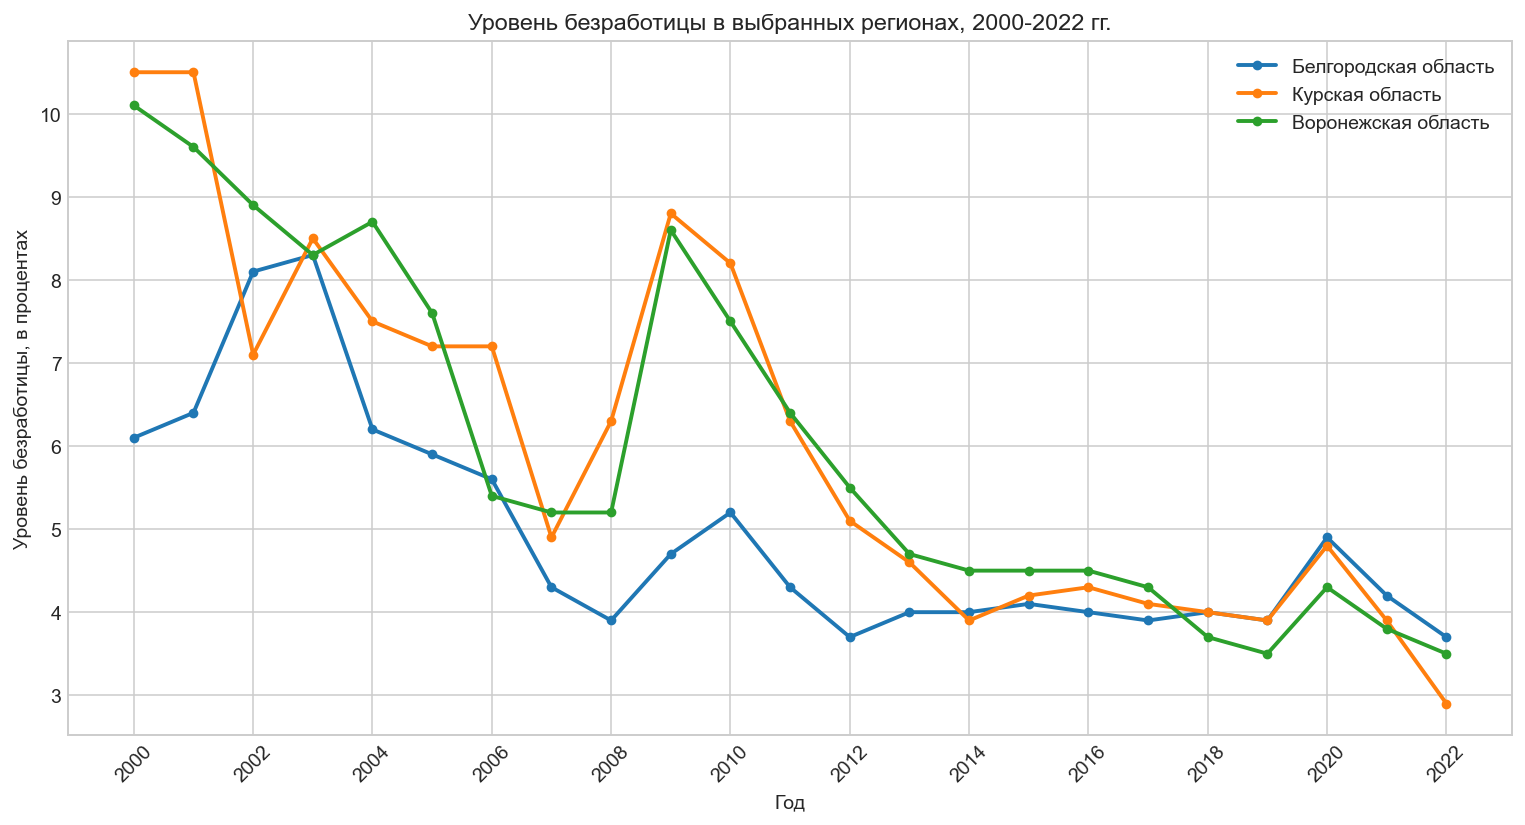

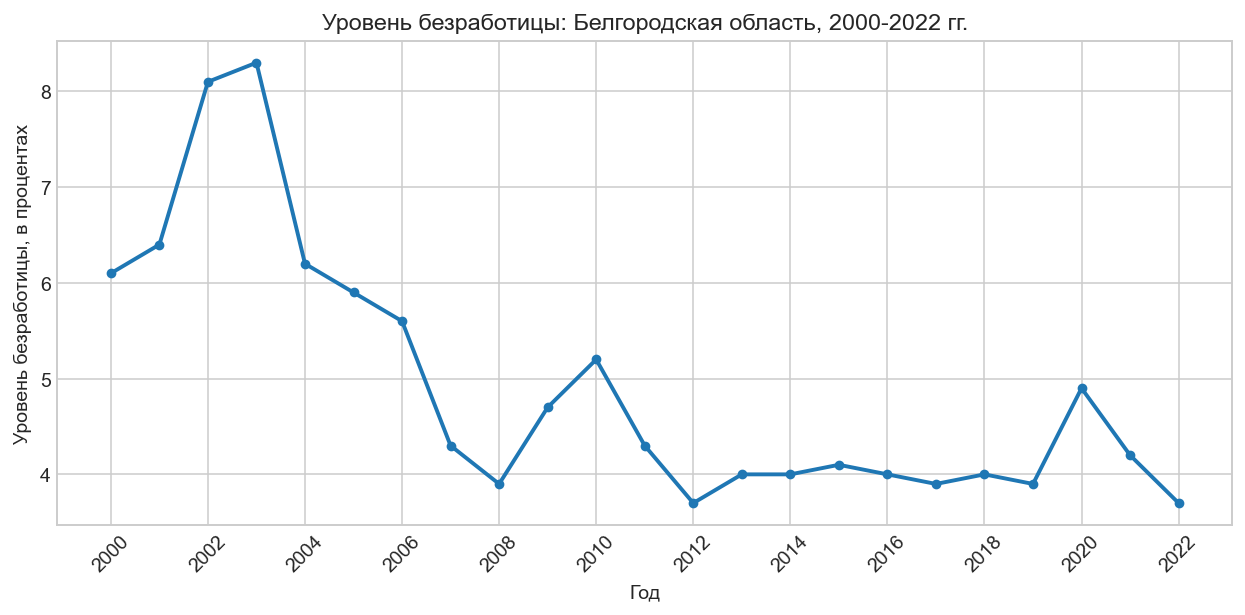

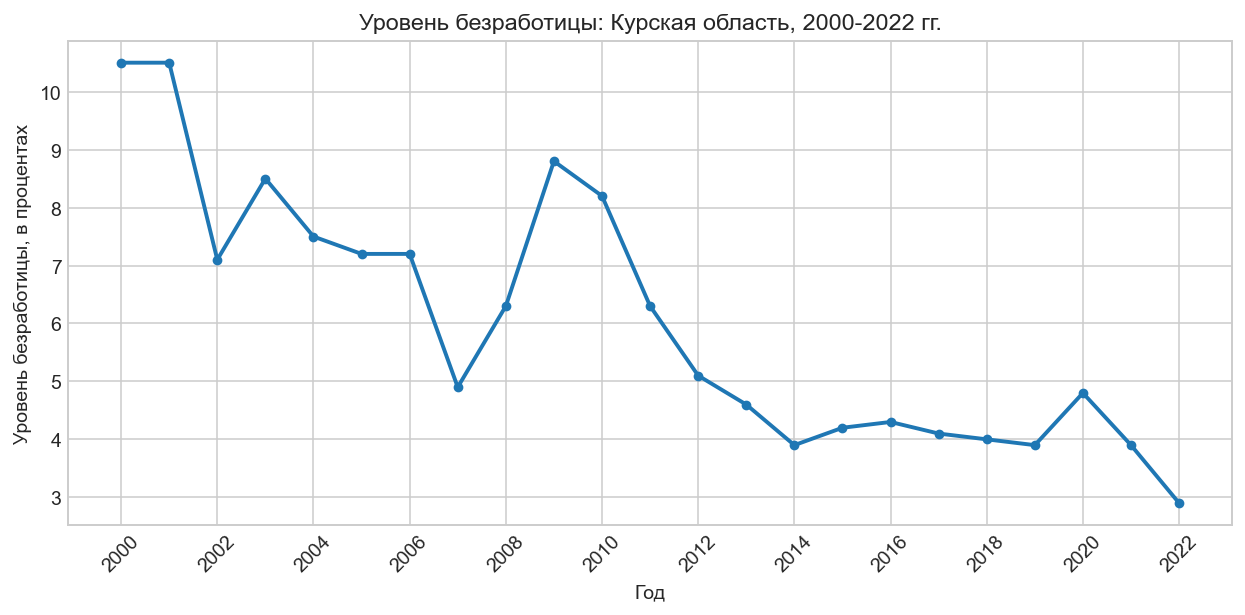

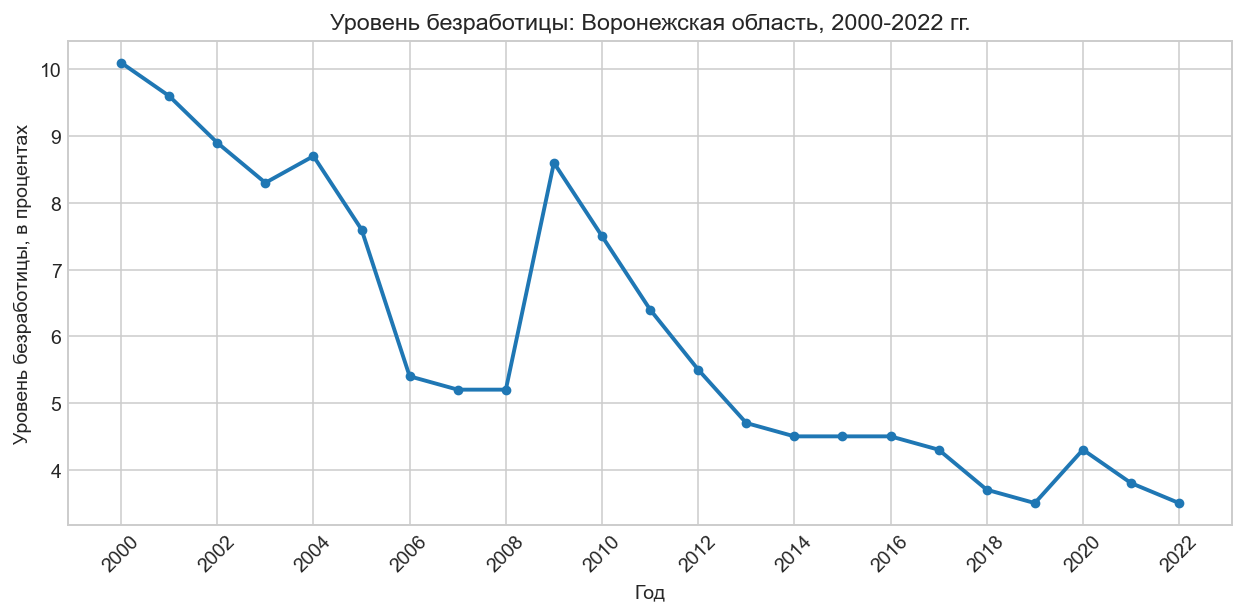

Сохраненные графики:
/Users/maria/Desktop/Code/HSE/TS/hw18/figures/unemployment_selected_regions_combined.png
/Users/maria/Desktop/Code/HSE/TS/hw18/figures/unemployment_belgorod_oblast.png
/Users/maria/Desktop/Code/HSE/TS/hw18/figures/unemployment_kursk_oblast.png
/Users/maria/Desktop/Code/HSE/TS/hw18/figures/unemployment_voronezh_oblast.png


In [6]:
plt.style.use("seaborn-v0_8-whitegrid")
saved_figures = []

combined_path = FIGURES_DIR / "unemployment_selected_regions_combined.png"
fig, ax = plt.subplots(figsize=(11, 6))
for region in SELECTED_REGIONS:
    ax.plot(
        wide_df["year"],
        wide_df[region],
        marker="o",
        linewidth=2,
        markersize=4,
        label=region,
    )
ax.set_title("Уровень безработицы в выбранных регионах, 2000-2022 гг.")
ax.set_xlabel("Год")
ax.set_ylabel(f"Уровень безработицы, {units.lower()}")
ax.legend()
ax.set_xticks(wide_df["year"][::2])
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(combined_path, bbox_inches="tight")
saved_figures.append(combined_path)
plt.show()

for region in SELECTED_REGIONS:
    fig_path = FIGURES_DIR / f"unemployment_{FILE_LABELS[region]}.png"
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(
        wide_df["year"],
        wide_df[region],
        color="#1f77b4",
        marker="o",
        linewidth=2,
        markersize=4,
    )
    ax.set_title(f"Уровень безработицы: {region}, 2000-2022 гг.")
    ax.set_xlabel("Год")
    ax.set_ylabel(f"Уровень безработицы, {units.lower()}")
    ax.set_xticks(wide_df["year"][::2])
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(fig_path, bbox_inches="tight")
    saved_figures.append(fig_path)
    plt.show()

print("Сохраненные графики:")
for path in saved_figures:
    print(path)

## 6. Описательная статистика

In [7]:
descriptive_stats = pd.DataFrame(
    {
        "mean": wide_df[SELECTED_REGIONS].mean(),
        "std": wide_df[SELECTED_REGIONS].std(),
        "min": wide_df[SELECTED_REGIONS].min(),
        "max": wide_df[SELECTED_REGIONS].max(),
        "first_value": wide_df.loc[0, SELECTED_REGIONS],
        "last_value": wide_df.loc[wide_df.index[-1], SELECTED_REGIONS],
        "total_change": wide_df.loc[wide_df.index[-1], SELECTED_REGIONS] - wide_df.loc[0, SELECTED_REGIONS],
    }
).round(3)

descriptive_stats.index.name = "регион"
display(descriptive_stats)

,mean,std,min,max,first_value,last_value,total_change
регион,,,,,,,
Белгородская область,4.930,1.344,3.7,8.3,6.1,3.7,-2.4
Курская область,6.030,2.215,2.9,10.5,10.5,2.9,-7.6
Воронежская область,6.013,2.145,3.5,10.1,10.1,3.5,-6.6


In [8]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 140

PROJECT_DIR = Path.cwd()
CLEAN_CSV_PATH = PROJECT_DIR / "data" / "clean_unemployment_regions.csv"
TABLES_DIR = PROJECT_DIR / "results" / "tables"
FIGURES_DIR = PROJECT_DIR / "figures" / "model_figures"
TABLES_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

manual_alpha = np.array([[1.0], [3.0]])
manual_B = np.array([[0.6, -0.2], [-0.1, 0.4]])
manual_identity = np.eye(2)
manual_I_minus_B = manual_identity - manual_B
manual_I_minus_B_inv = np.linalg.inv(manual_I_minus_B)

manual_eigvals = np.linalg.eigvals(manual_B)
manual_mean = np.linalg.solve(manual_identity - manual_B, manual_alpha)
manual_trace = np.trace(manual_B)
manual_det = np.linalg.det(manual_B)

manual_matrix_B_table = pd.DataFrame(manual_B, index=["y1", "y2"], columns=["y1(-1)", "y2(-1)"]).round(4)
manual_I_minus_B_table = pd.DataFrame(manual_I_minus_B, index=["y1", "y2"], columns=["y1", "y2"]).round(4)
manual_I_minus_B_inv_table = pd.DataFrame(manual_I_minus_B_inv, index=["y1", "y2"], columns=["y1", "y2"]).round(6)

manual_stationarity_table = pd.DataFrame(
    {
        "собственное значение": manual_eigvals,
        "модуль": np.abs(manual_eigvals),
        "внутри единичной окружности": np.abs(manual_eigvals) < 1,
    }
).round(6)
manual_stationarity_table.to_csv(
    TABLES_DIR / "manual_var1_stationarity_table.csv",
    index=False,
    encoding="utf-8-sig",
)

manual_mean_table = pd.DataFrame(
    {
        "компонента": ["y1", "y2"],
        "математическое ожидание": manual_mean.flatten(),
    }
).round(6)
manual_mean_table.to_csv(
    TABLES_DIR / "manual_var1_mean_table.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Матрица B")
display(manual_matrix_B_table)
print("Матрица I - B")
display(manual_I_minus_B_table)
print("Обратная матрица (I - B)^(-1)")
display(manual_I_minus_B_inv_table)
print("Собственные значения")
display(manual_stationarity_table)
print("Безусловное математическое ожидание")
display(manual_mean_table)

manual_stationarity_text = (
    "### Вывод\n\n"
    f"- Характеристический многочлен: $\\lambda^2 - {manual_trace:.4f}\\lambda + {manual_det:.4f} = 0$.\n"
    f"- Собственные значения: `{manual_eigvals[0]:.6f}` и `{manual_eigvals[1]:.6f}`.\n"
    "- Оба по модулю меньше 1, значит VAR(1) стационарна.\n"
    f"- $(I-B)^{{-1}} = {manual_I_minus_B_inv.round(6).tolist()}$.\n"
    f"- $\\mu = (I-B)^{{-1}}\\alpha = ({manual_mean[0, 0]:.6f}, {manual_mean[1, 0]:.6f})' \approx (0, 5)'$.\n"
)
display(Markdown(manual_stationarity_text))

Матрица B


,y1(-1),y2(-1)
y1,0.6,-0.2
y2,-0.1,0.4


Матрица I - B


,y1,y2
y1,0.4,0.2
y2,0.1,0.6


Обратная матрица (I - B)^(-1)


...

Собственные значения


,собственное значение,модуль,внутри единичной окружности
0,0.673205,0.673205,True
1,0.326795,0.326795,True


Безусловное математическое ожидание


,компонента,математическое ожидание
0,y1,0.0
1,y2,5.0


### Вывод

- Характеристический многочлен: $\lambda^2 - 1.0000\lambda + 0.2200 = 0$.
- Собственные значения: `0.673205` и `0.326795`.
- Оба по модулю меньше 1, значит VAR(1) стационарна.
- $(I-B)^{-1} = [[2.727273, -0.909091], [-0.454545, 1.818182]]$.
- $\mu = (I-B)^{-1}\alpha = (0.000000, 5.000000)' pprox (0, 5)'$.


# 2. Функция импульсного отклика

\[
IRF(1) = B,
\qquad
IRF(2) = B^2.
\]

IRF(1) = B


,шок y1,шок y2
y1,0.6,-0.2
y2,-0.1,0.4


IRF(2) = B^2


,шок y1,шок y2
y1,0.38,-0.20
y2,-0.10,0.18


Сводная таблица откликов


,шок,отклик,t=1,t=2
0,единичный шок в y1,y1,0.6,0.38
1,единичный шок в y1,y2,-0.1,-0.10
2,единичный шок в y2,y1,-0.2,-0.20
3,единичный шок в y2,y2,0.4,0.18


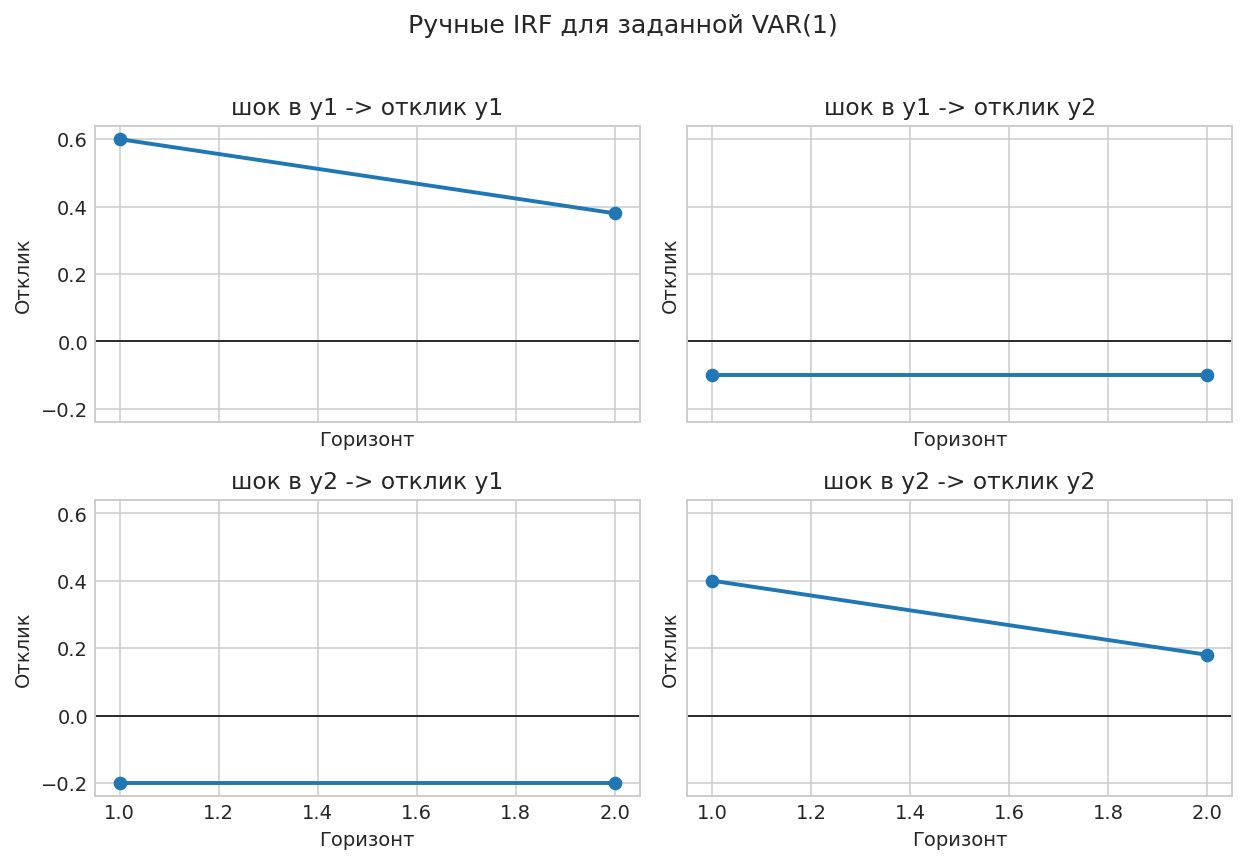

### Вывод

- Шок в `y1` дает положительный затухающий эффект на `y1` и слабый отрицательный эффект на `y2`.
- Шок в `y2` дает отрицательный эффект на `y1` и положительный затухающий эффект на `y2`.
- Переход от `IRF(1)` к `IRF(2)` показывает уменьшение откликов по модулю, что согласуется со стационарностью системы.


График ручных IRF сохранен: /Users/maria/Desktop/Code/HSE/TS/hw18/figures/manual_var1_irf.png


In [9]:
manual_B2 = manual_B @ manual_B

manual_irf_matrix_1 = pd.DataFrame(manual_B, index=["y1", "y2"], columns=["шок y1", "шок y2"]).round(6)
manual_irf_matrix_2 = pd.DataFrame(manual_B2, index=["y1", "y2"], columns=["шок y1", "шок y2"]).round(6)

manual_irf_table = pd.DataFrame(
    [
        {"шок": "единичный шок в y1", "отклик": "y1", "t=1": manual_B[0, 0], "t=2": manual_B2[0, 0]},
        {"шок": "единичный шок в y1", "отклик": "y2", "t=1": manual_B[1, 0], "t=2": manual_B2[1, 0]},
        {"шок": "единичный шок в y2", "отклик": "y1", "t=1": manual_B[0, 1], "t=2": manual_B2[0, 1]},
        {"шок": "единичный шок в y2", "отклик": "y2", "t=1": manual_B[1, 1], "t=2": manual_B2[1, 1]},
    ]
).round(6)
manual_irf_table.to_csv(
    TABLES_DIR / "manual_var1_irf_table.csv",
    index=False,
    encoding="utf-8-sig",
)

print("IRF(1) = B")
display(manual_irf_matrix_1)
print("IRF(2) = B^2")
display(manual_irf_matrix_2)
print("Сводная таблица откликов")
display(manual_irf_table)

manual_irf_fig_path = FIGURES_DIR / "manual_var1_irf.png"
fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharex=True, sharey=True)
manual_horizons = [1, 2]
manual_pairs = [
    ("шок в y1", "отклик y1", [manual_B[0, 0], manual_B2[0, 0]]),
    ("шок в y1", "отклик y2", [manual_B[1, 0], manual_B2[1, 0]]),
    ("шок в y2", "отклик y1", [manual_B[0, 1], manual_B2[0, 1]]),
    ("шок в y2", "отклик y2", [manual_B[1, 1], manual_B2[1, 1]]),
]

for ax, (shock_name, response_name, values) in zip(axes.flat, manual_pairs):
    ax.plot(manual_horizons, values, marker="o", linewidth=2)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{shock_name} -> {response_name}")
    ax.set_xlabel("Горизонт")
    ax.set_ylabel("Отклик")

fig.suptitle("Ручные IRF для заданной VAR(1)", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(manual_irf_fig_path, bbox_inches="tight")
plt.show()

manual_irf_text = (
    "### Вывод\n\n"
    "- Шок в `y1` дает положительный затухающий эффект на `y1` и слабый отрицательный эффект на `y2`.\n"
    "- Шок в `y2` дает отрицательный эффект на `y1` и положительный затухающий эффект на `y2`.\n"
    "- Переход от `IRF(1)` к `IRF(2)` показывает уменьшение откликов по модулю, что согласуется со стационарностью системы.\n"
)
display(Markdown(manual_irf_text))
print("График ручных IRF сохранен:", manual_irf_fig_path)

# 3. Эмпирическая часть: VAR-модель по региональной безработице

Ниже использую уже очищенный годовой набор данных по трем регионам и выполняю только эконометрический этап:
проверку стационарности, выбор лага, оценивание VAR, проверку устойчивости, диагностику остатков,
тесты причинности по Грейнджеру, IRF, FEVD, короткий прогноз и генерацию финального LaTeX-отчета.

## 8. Загрузка очищенного набора и проверка временного индекса

In [10]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss

PROJECT_DIR = Path.cwd()
CLEAN_CSV_PATH = PROJECT_DIR / "data" / "clean_unemployment_regions.csv"
TABLES_DIR = PROJECT_DIR / "results" / "tables"
FIGURES_DIR = PROJECT_DIR / "figures" / "model_figures"
TABLES_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

clean_df = pd.read_csv(CLEAN_CSV_PATH)
clean_df["year"] = clean_df["year"].astype(int)

expected_years = list(range(2000, 2023))
actual_years = clean_df["year"].tolist()
if actual_years != expected_years:
    raise ValueError(
        f"Ожидались годы {expected_years[0]}-{expected_years[-1]}, получено: {actual_years}"
    )

ts_df = clean_df.set_index(pd.PeriodIndex(clean_df["year"], freq="Y")).drop(columns="year")
regions = ts_df.columns.tolist()

index_check_table = pd.DataFrame(
    [
        {"проверка": "Частота индекса", "результат": str(ts_df.index.freqstr)},
        {"проверка": "Первый год", "результат": int(ts_df.index[0].year)},
        {"проверка": "Последний год", "результат": int(ts_df.index[-1].year)},
        {"проверка": "Число наблюдений", "результат": int(len(ts_df))},
        {"проверка": "Годы идут подряд", "результат": bool(actual_years == expected_years)},
    ]
)

display(index_check_table)
display(ts_df.head())

,проверка,результат
0,Частота индекса,Y-DEC
1,Первый год,2000
2,Последний год,2022
3,Число наблюдений,23
4,Годы идут подряд,True


,Белгородская область,Курская область,Воронежская область
year,,,
2000,6.1,10.5,10.1
2001,6.4,10.5,9.6
2002,8.1,7.1,8.9
2003,8.3,8.5,8.3
2004,6.2,7.5,8.7


## 9. Проверка стационарности

Для короткой годовой выборки (`T = 23`) использую ADF и KPSS в максимально прозрачной форме.

- `ADF`: нулевая гипотеза `H0` утверждает, что ряд имеет единичный корень, то есть нестационарен.
- `KPSS`: нулевая гипотеза `H0` утверждает, что ряд стационарен.

Если по уровням стационарность не подтверждается, тестирую первые разности.
Чтобы не перегружать ADF на маленькой выборке, ограничиваю максимальный лаг `maxlag = 3`, а дальше лаг выбирается по `AIC`.

In [11]:
ADF_MAXLAG = 3


def format_pvalue(value):
    return float(value) if value is not None else np.nan


def adf_conclusion(pvalue):
    if pvalue < 0.05:
        return "ADF: отвергаем H0, единичный корень не подтверждается"
    return "ADF: не отвергаем H0, есть признаки нестационарности"


def kpss_conclusion(pvalue):
    if pvalue < 0.05:
        return "KPSS: отвергаем H0, стационарность отвергается"
    return "KPSS: не отвергаем H0, стационарность не отвергается"


def combined_conclusion(adf_pvalue, kpss_pvalue):
    if adf_pvalue < 0.05 and kpss_pvalue >= 0.05:
        return "Ряд стационарен"
    if adf_pvalue >= 0.05 and kpss_pvalue < 0.05:
        return "Ряд нестационарен"
    return "Результат неоднозначен"


def run_stationarity_tests(dataframe, form_label):
    rows = []
    for region in dataframe.columns:
        series = dataframe[region].dropna()

        with warnings.catch_warnings(record=True) as adf_warns:
            warnings.simplefilter("always")
            adf_stat, adf_pvalue, usedlag, nobs, critical_values, icbest = adfuller(
                series,
                maxlag=ADF_MAXLAG,
                autolag="AIC",
            )

        with warnings.catch_warnings(record=True) as kpss_warns:
            warnings.simplefilter("always")
            kpss_stat, kpss_pvalue, kpss_lags, kpss_critical = kpss(
                series,
                regression="c",
                nlags="auto",
            )

        rows.append(
            {
                "регион": region,
                "форма_ряда": form_label,
                "ADF статистика": adf_stat,
                "ADF p-value": format_pvalue(adf_pvalue),
                "ADF лаг": int(usedlag),
                "ADF вывод": adf_conclusion(adf_pvalue),
                "KPSS статистика": kpss_stat,
                "KPSS p-value": format_pvalue(kpss_pvalue),
                "KPSS лаг": int(kpss_lags),
                "KPSS вывод": kpss_conclusion(kpss_pvalue),
                "итог": combined_conclusion(adf_pvalue, kpss_pvalue),
                "примечание": "; ".join(str(w.message) for w in adf_warns + kpss_warns),
            }
        )

    return pd.DataFrame(rows)


stationarity_levels = run_stationarity_tests(ts_df, "Уровни")
diff_df = ts_df.diff().dropna()
stationarity_diffs = run_stationarity_tests(diff_df, "Первые разности")
stationarity_table = pd.concat([stationarity_levels, stationarity_diffs], ignore_index=True)

levels_are_stationary = (stationarity_levels["итог"] == "Ряд стационарен").all()
diffs_are_stationary = (stationarity_diffs["итог"] == "Ряд стационарен").all()
use_differences = (not levels_are_stationary) and diffs_are_stationary

if use_differences:
    analysis_df = diff_df.copy()
    transformation_used = "Первые разности уровней безработицы"
    transformation_reason = (
        "Во всех трех регионах уровни не проходят совместную проверку на стационарность, "
        "тогда как первые разности выглядят стационарными по комбинации ADF и KPSS."
    )
else:
    analysis_df = ts_df.copy()
    transformation_used = "Уровни"
    transformation_reason = (
        "Ряды в уровнях признаны стационарными, поэтому дополнительное дифференцирование не требуется."
    )

stationarity_table = stationarity_table.round(4)
stationarity_table.to_csv(TABLES_DIR / "stationarity_table.csv", index=False, encoding="utf-8-sig")

display(stationarity_table)
print("Выбранная форма ряда:", transformation_used)
print("Обоснование:", transformation_reason)

,регион,форма_ряда,ADF статистика,ADF p-value,ADF лаг,ADF вывод,KPSS статистика,KPSS p-value,KPSS лаг,KPSS вывод,итог,примечание
0,Белгородская область,Уровни,-2.3661,0.1515,2,"ADF: не отвергаем H0, есть признаки нестациона...",0.4928,0.0433,3,"KPSS: отвергаем H0, стационарность отвергается",Ряд нестационарен,
1,Курская область,Уровни,-1.8857,0.3388,0,"ADF: не отвергаем H0, есть признаки нестациона...",0.6467,0.0184,3,"KPSS: отвергаем H0, стационарность отвергается",Ряд нестационарен,
2,Воронежская область,Уровни,-1.7302,0.4156,0,"ADF: не отвергаем H0, есть признаки нестациона...",0.6320,0.0197,3,"KPSS: отвергаем H0, стационарность отвергается",Ряд нестационарен,
3,Белгородская область,Первые разности,-3.9335,0.0018,0,"ADF: отвергаем H0, единичный корень не подтвер...",0.0651,0.1000,0,"KPSS: не отвергаем H0, стационарность не отвер...",Ряд стационарен,The test statistic is outside of the range of ...
4,Курская область,Первые разности,-4.6801,0.0001,1,"ADF: отвергаем H0, единичный корень не подтвер...",0.0644,0.1000,1,"KPSS: не отвергаем H0, стационарность не отвер...",Ряд стационарен,The test statistic is outside of the range of ...
5,Воронежская область,Первые разности,-4.0135,0.0013,2,"ADF: отвергаем H0, единичный корень не подтвер...",0.0733,0.1000,0,"KPSS: не отвергаем H0, стационарность не отвер...",Ряд стационарен,The test statistic is outside of the range of ...


Выбранная форма ряда: Первые разности уровней безработицы
Обоснование: Во всех трех регионах уровни не проходят совместную проверку на стационарность, тогда как первые разности выглядят стационарными по комбинации ADF и KPSS.


In [12]:
n_vars = analysis_df.shape[1]
candidate_lags = []
lag_rows = []

for lag in [1, 2, 3]:
    effective_obs = len(analysis_df) - lag
    params_per_equation = 1 + n_vars * lag
    if effective_obs <= params_per_equation:
        continue

    candidate_lags.append(lag)
    fit = VAR(analysis_df).fit(lag)
    lag_rows.append(
        {
            "лаг": lag,
            "эффективные наблюдения": effective_obs,
            "параметров на уравнение": params_per_equation,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "HQIC": fit.hqic,
            "FPE": fit.fpe,
        }
    )

if not lag_rows:
    raise ValueError("Для VAR не осталось допустимых лагов при данной выборке.")

lag_selection_table = pd.DataFrame(lag_rows).round(4)

ic_columns = ["AIC", "BIC", "HQIC"]
ic_winners = {
    column: int(lag_selection_table.loc[lag_selection_table[column].idxmin(), "лаг"])
    for column in ic_columns
}

selected_lag = 3
if selected_lag not in candidate_lags:
    selected_lag = int(lag_selection_table.sort_values(["BIC", "AIC", "HQIC"]).iloc[0]["лаг"])

lag_selection_reason = (
    "Среди допустимых моделей p=1,2,3 лаг p=3 дает минимальные AIC, BIC и HQIC. "
    "При этом выборка мала, поэтому VAR(3) остается достаточно параметризованной; "
    "ее сохраняем как основную модель, но интерпретируем осторожно и отдельно проверяем устойчивость вывода на VAR(1) и VAR(2)."
)

lag_selection_table.to_csv(TABLES_DIR / "lag_selection_table.csv", index=False, encoding="utf-8-sig")

display(lag_selection_table)
print("Победители по информационным критериям:", ic_winners)
print("Выбранный лаг:", selected_lag)
print("Обоснование:", lag_selection_reason)

,лаг,эффективные наблюдения,параметров на уравнение,AIC,BIC,HQIC,FPE
0,1,21,4,0.0695,0.6664,0.1990,1.0872
1,2,20,7,-1.6353,-0.5898,-1.4312,0.2138
2,3,19,10,-2.2163,-0.7251,-1.9640,0.1550


Победители по информационным критериям: {'AIC': 3, 'BIC': 3, 'HQIC': 3}
Выбранный лаг: 3
Обоснование: Среди допустимых моделей p=1,2,3 лаг p=3 дает минимальные AIC, BIC и HQIC. При этом выборка мала, поэтому VAR(3) остается достаточно параметризованной; ее сохраняем как основную модель, но интерпретируем осторожно и отдельно проверяем устойчивость вывода на VAR(1) и VAR(2).


In [13]:
var_model = VAR(analysis_df)
var_results = var_model.fit(selected_lag)

coefficient_rows = []
for equation in analysis_df.columns:
    for parameter in var_results.params.index:
        coefficient_rows.append(
            {
                "уравнение": equation,
                "параметр": parameter,
                "коэффициент": var_results.params.loc[parameter, equation],
                "стандартная ошибка": var_results.stderr.loc[parameter, equation],
                "t-статистика": var_results.tvalues.loc[parameter, equation],
                "p-value": var_results.pvalues.loc[parameter, equation],
            }
        )

var_coefficients_table = pd.DataFrame(coefficient_rows).round(4)
var_coefficients_table.to_csv(
    TABLES_DIR / "var_coefficients_table.csv",
    index=False,
    encoding="utf-8-sig",
)

display(var_coefficients_table)

,уравнение,параметр,коэффициент,стандартная ошибка,t-статистика,p-value
0,Белгородская область,const,-0.2256,0.1951,-1.1563,0.2476
1,Белгородская область,L1.Белгородская область,0.0204,0.4233,0.0481,0.9616
2,Белгородская область,L1.Курская область,-0.2771,0.3668,-0.7554,0.4500
3,Белгородская область,L1.Воронежская область,0.4154,0.3387,1.2266,0.2200
4,Белгородская область,L2.Белгородская область,-0.4473,0.2396,-1.8670,0.0619
5,Белгородская область,L2.Курская область,-0.0827,0.3533,-0.2342,0.8148
6,Белгородская область,L2.Воронежская область,0.1208,0.4009,0.3013,0.7632
7,Белгородская область,L3.Белгородская область,-0.0465,0.3486,-0.1333,0.8939
8,Белгородская область,L3.Курская область,-0.0355,0.2474,-0.1435,0.8859
9,Белгородская область,L3.Воронежская область,-0.0242,0.2703,-0.0897,0.9285


,корень_характеристического_полинома,модуль_корня,собственное_значение_companion,модуль_собственного_значения,внутри_единичной_окружности
7,0.6379+1.0524j,1.2306,0.4212-0.6949j,0.8126,True
8,0.6379-1.0524j,1.2306,0.4212+0.6949j,0.8126,True
5,-0.9245+0.9748j,1.3434,-0.5122-0.5401j,0.7444,True
6,-0.9245-0.9748j,1.3434,-0.5122+0.5401j,0.7444,True
3,-0.0145+1.3585j,1.3586,-0.0079-0.7360j,0.7361,True
4,-0.0145-1.3585j,1.3586,-0.0079+0.7360j,0.7361,True
2,-1.9340-0.0000j,1.9340,-0.5171-0.0000j,0.5171,True
0,2.2515+0.5730j,2.3232,0.4171-0.1062j,0.4304,True
1,2.2515-0.5730j,2.3232,0.4171+0.1062j,0.4304,True


VAR устойчива: True


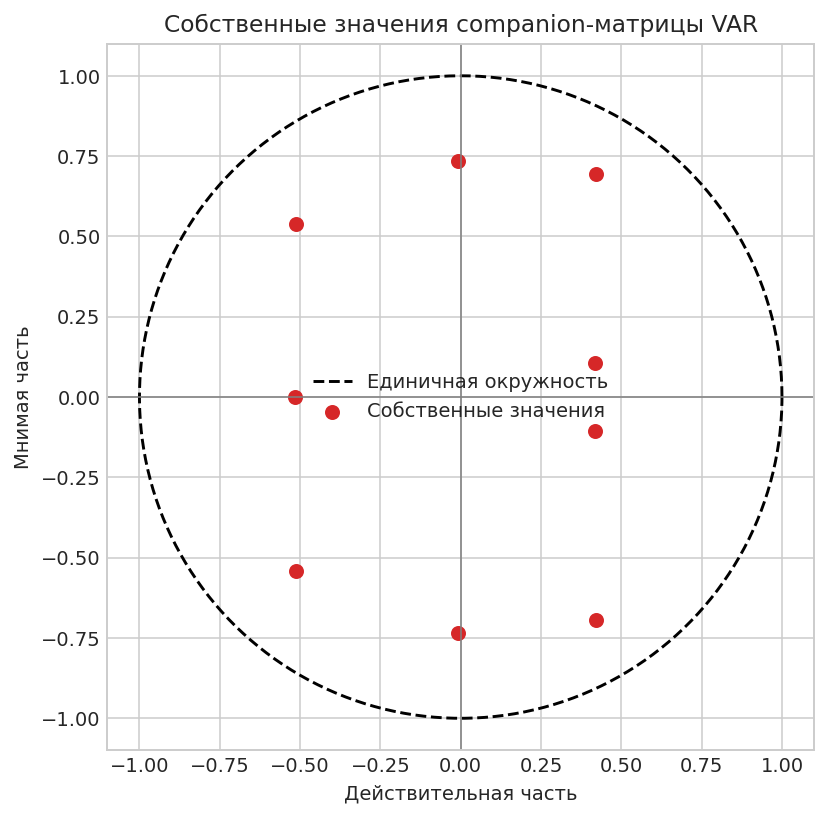

График устойчивости сохранен: /Users/maria/Desktop/Code/HSE/TS/hw18/figures/var_inverse_roots.png


In [14]:
def format_complex(value):
    return f"{value.real:.4f}{value.imag:+.4f}j"


characteristic_roots = var_results.roots
companion_eigenvalues = 1 / characteristic_roots

stability_table = pd.DataFrame(
    {
        "корень_характеристического_полинома": [format_complex(value) for value in characteristic_roots],
        "модуль_корня": np.abs(characteristic_roots),
        "собственное_значение_companion": [format_complex(value) for value in companion_eigenvalues],
        "модуль_собственного_значения": np.abs(companion_eigenvalues),
        "внутри_единичной_окружности": np.abs(companion_eigenvalues) < 1,
    }
).sort_values("модуль_собственного_значения", ascending=False)

var_is_stable = bool(var_results.is_stable())
stability_table = stability_table.round(4)
stability_table.to_csv(TABLES_DIR / "stability_roots_table.csv", index=False, encoding="utf-8-sig")

display(stability_table)
print("VAR устойчива:", var_is_stable)

unit_circle = np.linspace(0, 2 * np.pi, 400)
roots_fig_path = FIGURES_DIR / "var_inverse_roots.png"

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(np.cos(unit_circle), np.sin(unit_circle), linestyle="--", color="black", label="Единичная окружность")
ax.scatter(
    companion_eigenvalues.real,
    companion_eigenvalues.imag,
    color="#d62728",
    s=45,
    label="Собственные значения",
)
ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_title("Собственные значения companion-матрицы VAR")
ax.set_xlabel("Действительная часть")
ax.set_ylabel("Мнимая часть")
ax.set_aspect("equal", adjustable="box")
ax.legend()
fig.tight_layout()
fig.savefig(roots_fig_path, bbox_inches="tight")
plt.show()

print("График устойчивости сохранен:", roots_fig_path)

,тест,H0,статистика,p-value,вывод
0,Portmanteau на автокорреляцию остатков,Автокорреляции остатков нет,23.6844,0.1656,H0 не отвергается
1,Portmanteau на автокорреляцию остатков (small-...,Автокорреляции остатков нет,27.6857,0.0670,H0 не отвергается
2,Тест нормальности остатков,Остатки нормальны,8.7360,0.1890,H0 не отвергается


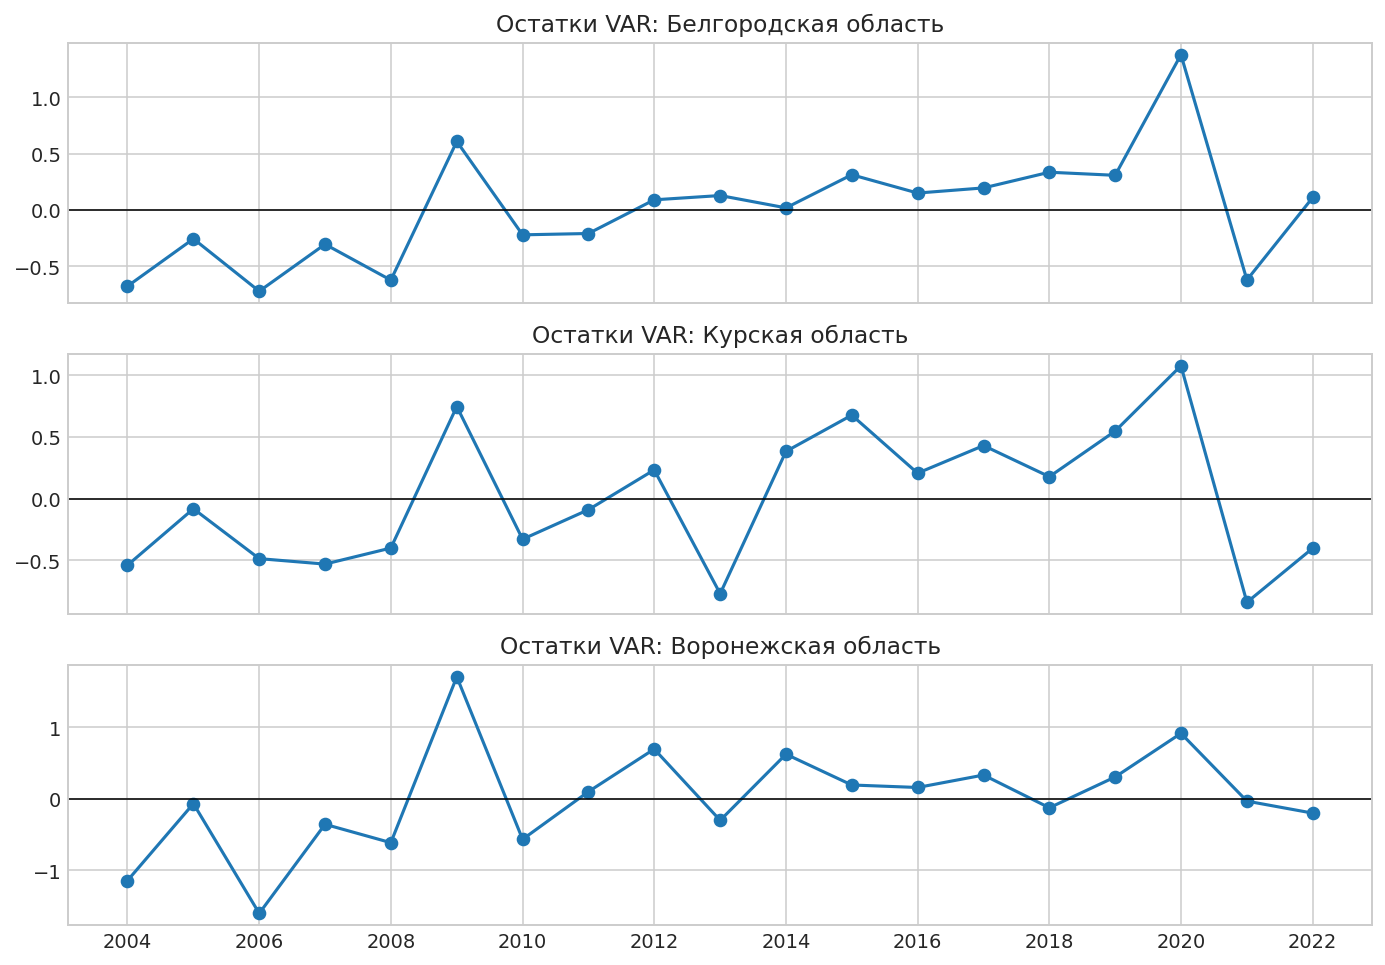

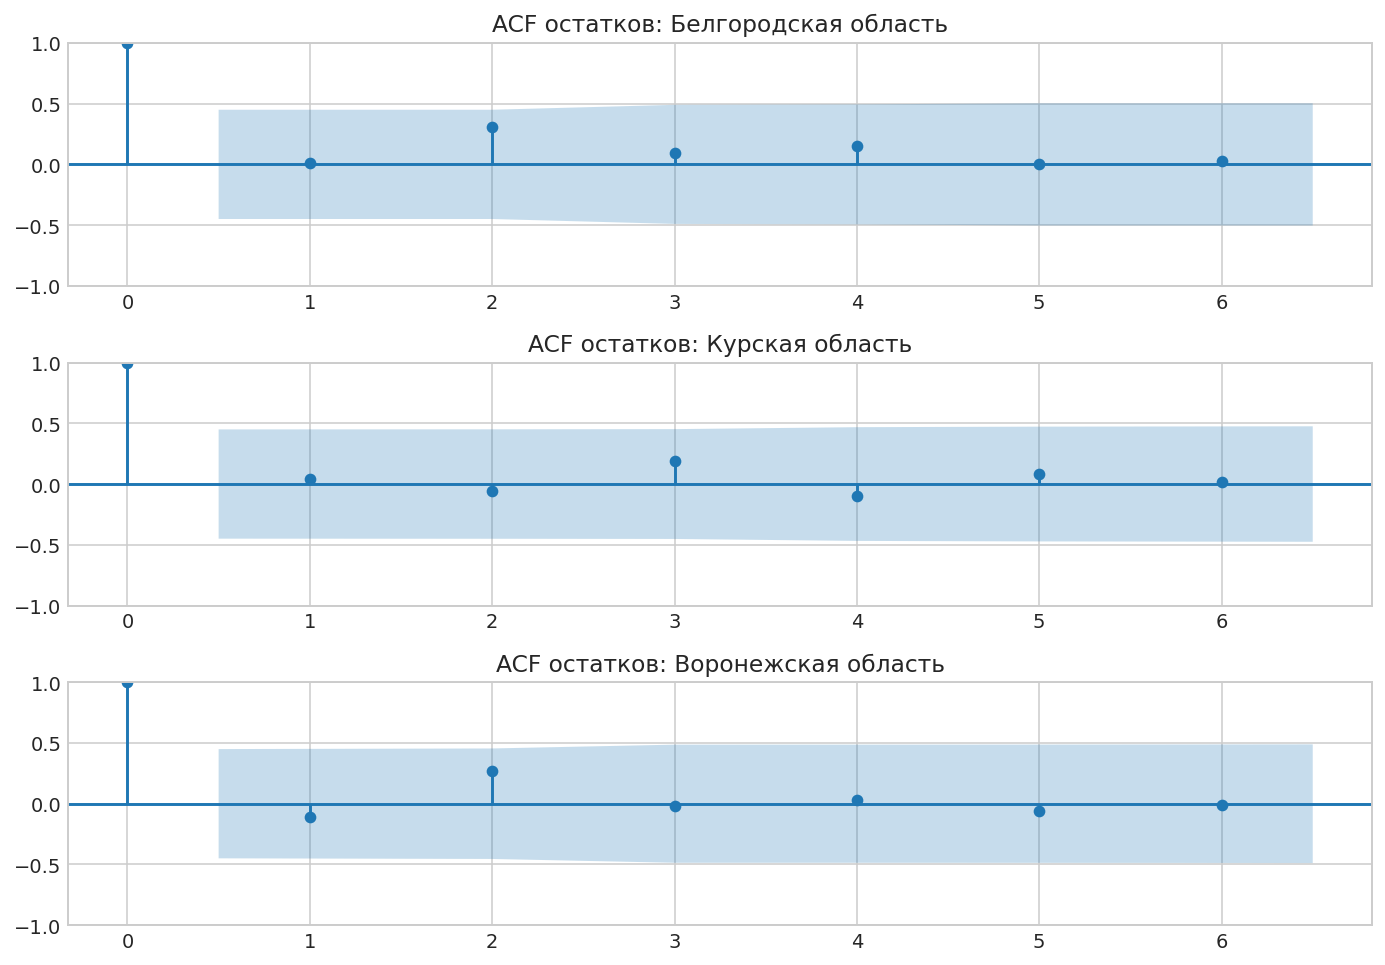

Графики остатков сохранены:
/Users/maria/Desktop/Code/HSE/TS/hw18/figures/var_residuals.png
/Users/maria/Desktop/Code/HSE/TS/hw18/figures/var_residuals_acf.png


In [15]:
whiteness_test = var_results.test_whiteness(nlags=5, adjusted=False)
whiteness_test_adjusted = var_results.test_whiteness(nlags=5, adjusted=True)
normality_test = var_results.test_normality()

diagnostics_table = pd.DataFrame(
    [
        {
            "тест": "Portmanteau на автокорреляцию остатков",
            "H0": "Автокорреляции остатков нет",
            "статистика": whiteness_test.test_statistic,
            "p-value": whiteness_test.pvalue,
            "вывод": "H0 не отвергается" if whiteness_test.pvalue >= 0.05 else "H0 отвергается",
        },
        {
            "тест": "Portmanteau на автокорреляцию остатков (small-sample adjusted)",
            "H0": "Автокорреляции остатков нет",
            "статистика": whiteness_test_adjusted.test_statistic,
            "p-value": whiteness_test_adjusted.pvalue,
            "вывод": "H0 не отвергается" if whiteness_test_adjusted.pvalue >= 0.05 else "H0 отвергается",
        },
        {
            "тест": "Тест нормальности остатков",
            "H0": "Остатки нормальны",
            "статистика": normality_test.test_statistic,
            "p-value": normality_test.pvalue,
            "вывод": "H0 не отвергается" if normality_test.pvalue >= 0.05 else "H0 отвергается",
        },
    ]
).round(4)

diagnostics_table.to_csv(TABLES_DIR / "diagnostics_table.csv", index=False, encoding="utf-8-sig")
display(diagnostics_table)

residuals = var_results.resid.copy()
residuals_plot_path = FIGURES_DIR / "var_residuals.png"
residuals_acf_path = FIGURES_DIR / "var_residuals_acf.png"

fig, axes = plt.subplots(len(regions), 1, figsize=(10, 7), sharex=True)
for idx, region in enumerate(regions):
    axes[idx].plot(residuals.index.to_timestamp(), residuals[region], marker="o", linewidth=1.6)
    axes[idx].axhline(0, color="black", linewidth=0.8)
    axes[idx].set_title(f"Остатки VAR: {region}")
fig.tight_layout()
fig.savefig(residuals_plot_path, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(len(regions), 1, figsize=(10, 7))
max_acf_lag = min(6, len(residuals) - 1)
for idx, region in enumerate(regions):
    plot_acf(residuals[region], ax=axes[idx], lags=max_acf_lag, title=f"ACF остатков: {region}")
fig.tight_layout()
fig.savefig(residuals_acf_path, bbox_inches="tight")
plt.show()

print("Графики остатков сохранены:")
print(residuals_plot_path)
print(residuals_acf_path)

In [16]:
granger_rows = []

for caused in regions:
    for causing in regions:
        if caused == causing:
            continue

        causality_test = var_results.test_causality(caused=caused, causing=[causing], kind="f")
        is_significant = causality_test.pvalue < 0.05

        granger_rows.append(
            {
                "направление": f"{causing} -> {caused}",
                "регион_X": causing,
                "регион_Y": caused,
                "F-статистика": causality_test.test_statistic,
                "p-value": causality_test.pvalue,
                "вывод": (
                    "Отвергаем H0: изменения безработицы в X помогают прогнозировать изменения безработицы в Y"
                    if is_significant
                    else "Не отвергаем H0: значимой Granger-связи для изменений безработицы не найдено"
                ),
            }
        )

granger_table = pd.DataFrame(granger_rows).sort_values("p-value").round(4)
granger_table.to_csv(TABLES_DIR / "granger_causality_table.csv", index=False, encoding="utf-8-sig")

display(granger_table)

significant_links = granger_table.loc[
    granger_table["p-value"] < 0.05,
    "направление",
].tolist()

if significant_links:
    scheme_text = "### Схема значимых Granger-связей для изменений безработицы\n\n" + "\n".join(
        f"- изменения безработицы: {link}" for link in significant_links
    )
else:
    scheme_text = "### Схема значимых Granger-связей для изменений безработицы\n\n- Значимых направленных связей при уровне значимости 5% не найдено."

display(Markdown(scheme_text))

,направление,регион_X,регион_Y,F-статистика,p-value,вывод
3,Воронежская область -> Курская область,Воронежская область,Курская область,5.0123,0.0068,Отвергаем H0: изменения безработицы в X помога...
5,Курская область -> Воронежская область,Курская область,Воронежская область,1.8074,0.1696,Не отвергаем H0: значимой Granger-связи для из...
4,Белгородская область -> Воронежская область,Белгородская область,Воронежская область,1.1761,0.3372,Не отвергаем H0: значимой Granger-связи для из...
2,Белгородская область -> Курская область,Белгородская область,Курская область,1.0440,0.3890,Не отвергаем H0: значимой Granger-связи для из...
1,Воронежская область -> Белгородская область,Воронежская область,Белгородская область,0.6899,0.5661,Не отвергаем H0: значимой Granger-связи для из...
0,Курская область -> Белгородская область,Курская область,Белгородская область,0.2819,0.8380,Не отвергаем H0: значимой Granger-связи для из...


### Схема значимых Granger-связей для изменений безработицы

- изменения безработицы: Воронежская область -> Курская область

In [17]:
robustness_rows = []

for lag in [1, 2, 3]:
    fit = VAR(analysis_df).fit(lag)
    whiteness_unadjusted = fit.test_whiteness(nlags=5, adjusted=False)
    whiteness_adjusted = fit.test_whiteness(nlags=5, adjusted=True)
    normality = fit.test_normality()

    lag_links = []
    for caused in regions:
        for causing in regions:
            if caused == causing:
                continue
            pvalue = fit.test_causality(caused=caused, causing=[causing], kind="f").pvalue
            if pvalue < 0.05:
                lag_links.append(f"{causing} -> {caused}")

    robustness_rows.append(
        {
            "лаг": lag,
            "VAR устойчива": bool(fit.is_stable()),
            "p-value Portmanteau": whiteness_unadjusted.pvalue,
            "p-value Portmanteau adjusted": whiteness_adjusted.pvalue,
            "p-value нормальности": normality.pvalue,
            "значимые Granger-связи для изменений безработицы": "; ".join(lag_links) if lag_links else "нет",
        }
    )

robustness_table = pd.DataFrame(robustness_rows).round(4)
robustness_table.to_csv(TABLES_DIR / "robustness_var_comparison_table.csv", index=False, encoding="utf-8-sig")
display(robustness_table)

robustness_text = (
    "### Краткий robustness-комментарий\n\n"
    "- `VAR(1)` устойчива, но small-sample adjusted тест на автокорреляцию отвергает `H0`, "
    "а тест нормальности тоже дает явные проблемы.\n"
    "- `VAR(2)` устойчива и уже показывает ту же направленную Granger-связь "
    "`Воронежская область -> Курская область`, но adjusted тест на автокорреляцию остатков остается проблемным.\n"
    "- `VAR(3)` также устойчива, сохраняет ту же единственную значимую Granger-связь и выглядит лучшей среди трех моделей по совокупности "
    "информационных критериев и диагностик, хотя при такой малой выборке остается параметрически тяжелой.\n"
)

display(Markdown(robustness_text))

,лаг,VAR устойчива,p-value Portmanteau,p-value Portmanteau adjusted,p-value нормальности,значимые Granger-связи для изменений безработицы
0,1,True,0.0944,0.0164,0.000,нет
1,2,True,0.0209,0.0023,0.815,Воронежская область -> Курская область
2,3,True,0.1656,0.0670,0.189,Воронежская область -> Курская область


### Краткий robustness-комментарий

- `VAR(1)` устойчива, но small-sample adjusted тест на автокорреляцию отвергает `H0`, а тест нормальности тоже дает явные проблемы.
- `VAR(2)` устойчива и уже показывает ту же направленную Granger-связь `Воронежская область -> Курская область`, но adjusted тест на автокорреляцию остатков остается проблемным.
- `VAR(3)` также устойчива, сохраняет ту же единственную значимую Granger-связь и выглядит лучшей среди трех моделей по совокупности информационных критериев и диагностик, хотя при такой малой выборке остается параметрически тяжелой.


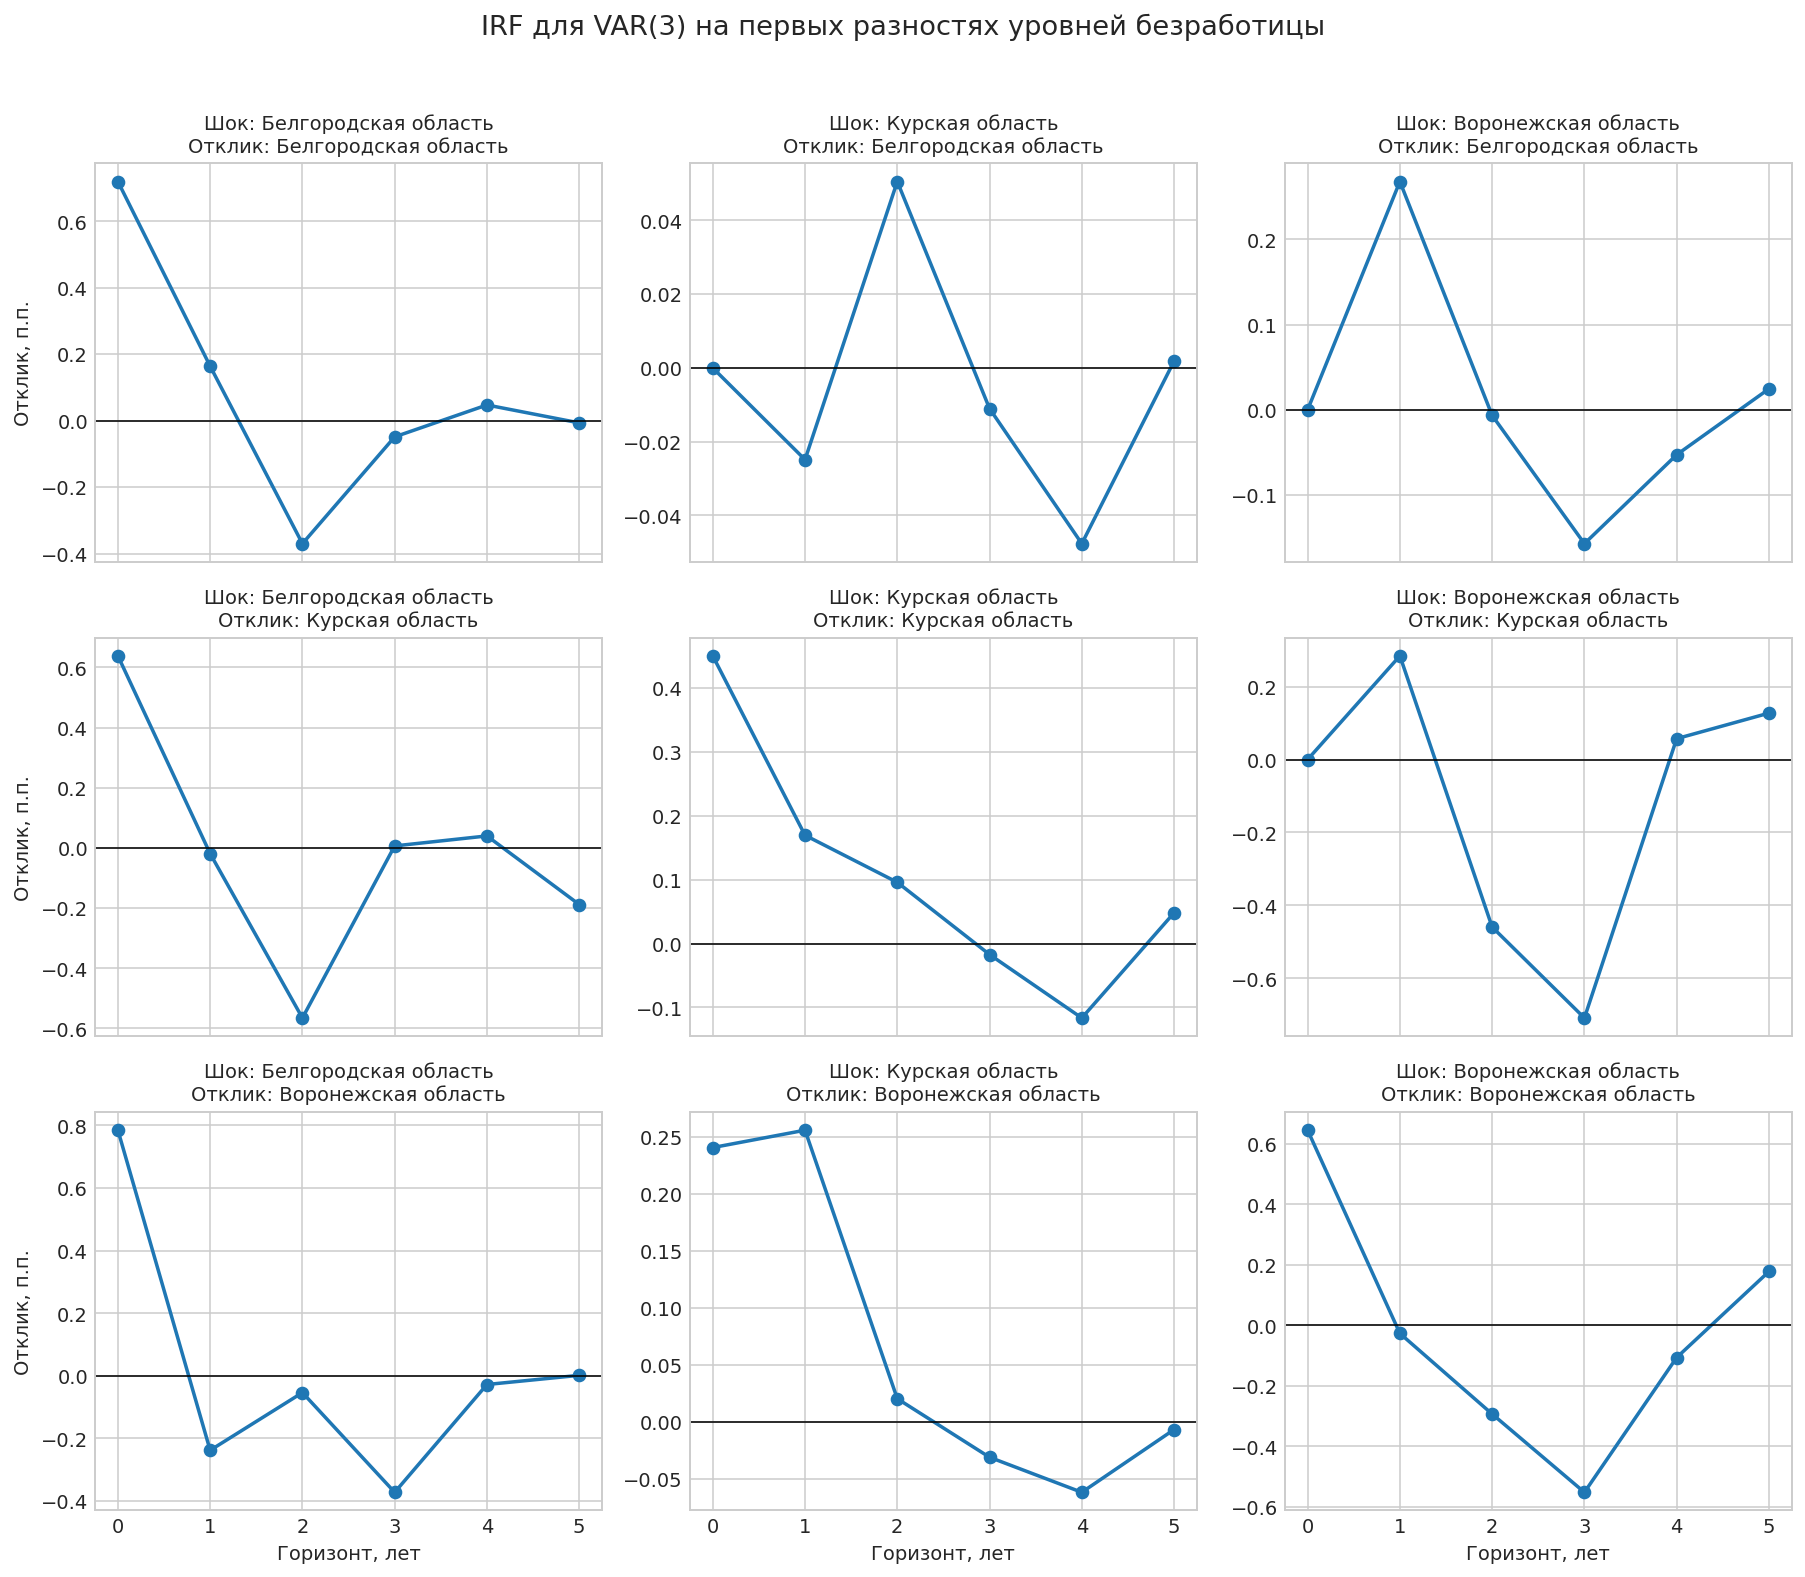

### Краткая интерпретация IRF

- Наиболее сильный отклик по модулю наблюдается для пары `Воронежская область -> Курская область` на горизонте 3 года: `-0.708` п.п.
- В динамике есть как положительные, так и отрицательные реакции, то есть отклики могут менять знак по мере распространения шока.
- По модулю отклики к горизонту 5 лет уменьшаются (максимум снижается с `0.708` до `0.188`), что согласуется с устойчивостью оцененной VAR.
- Особенно заметна связь между изменениями безработицы в Воронежской и Курской областях, что хорошо согласуется с результатами тестов Грейнджера.


IRF-график сохранен: /Users/maria/Desktop/Code/HSE/TS/hw18/figures/var_irf_orth_5y.png


In [19]:
irf_horizon = 5
irf_results = var_results.irf(irf_horizon)
orth_irf_array = irf_results.orth_irfs

irf_rows = []
for horizon in range(irf_horizon + 1):
    for response_idx, response_region in enumerate(regions):
        for impulse_idx, impulse_region in enumerate(regions):
            irf_rows.append(
                {
                    "горизонт": horizon,
                    "шок": impulse_region,
                    "отклик": response_region,
                    "IRF": orth_irf_array[horizon, response_idx, impulse_idx],
                }
            )

irf_table = pd.DataFrame(irf_rows).round(4)
irf_table.to_csv(TABLES_DIR / "irf_table.csv", index=False, encoding="utf-8-sig")

irf_fig_path = FIGURES_DIR / "var_irf_orth_5y.png"
fig, axes = plt.subplots(len(regions), len(regions), figsize=(13, 11), sharex=True)

for response_idx, response_region in enumerate(regions):
    for impulse_idx, impulse_region in enumerate(regions):
        ax = axes[response_idx, impulse_idx]
        values = orth_irf_array[:, response_idx, impulse_idx]
        ax.plot(range(irf_horizon + 1), values, marker="o", linewidth=1.8, color="#1f77b4")
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(f"Шок: {impulse_region}\nОтклик: {response_region}", fontsize=10)
        if response_idx == len(regions) - 1:
            ax.set_xlabel("Горизонт, лет")
        if impulse_idx == 0:
            ax.set_ylabel("Отклик, п.п.")

fig.suptitle("IRF для VAR(3) на первых разностях уровней безработицы", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(irf_fig_path, bbox_inches="tight")
plt.show()

nontrivial_irf = irf_table[irf_table["горизонт"] > 0].copy()
strongest_irf_row = nontrivial_irf.loc[nontrivial_irf["IRF"].abs().idxmax()]
max_initial_effect = nontrivial_irf["IRF"].abs().max()
max_terminal_effect = irf_table.loc[irf_table["горизонт"] == irf_horizon, "IRF"].abs().max()

irf_summary_text = (
    "### Краткая интерпретация IRF\n\n"
    f"- Наиболее сильный отклик по модулю наблюдается для пары "
    f"`{strongest_irf_row['шок']} -> {strongest_irf_row['отклик']}` "
    f"на горизонте {int(strongest_irf_row['горизонт'])} года: `{strongest_irf_row['IRF']:.3f}` п.п.\n"
    "- В динамике есть как положительные, так и отрицательные реакции, то есть отклики могут менять знак по мере распространения шока.\n"
    f"- По модулю отклики к горизонту {irf_horizon} лет уменьшаются "
    f"(максимум снижается с `{max_initial_effect:.3f}` до `{max_terminal_effect:.3f}`), "
    "что согласуется с устойчивостью оцененной VAR.\n"
    "- Особенно заметна связь между изменениями безработицы в Воронежской и Курской областях, "
    "что хорошо согласуется с результатами тестов Грейнджера.\n"
)

display(Markdown(irf_summary_text))
print("IRF-график сохранен:", irf_fig_path)

,отклик,горизонт,Белгородская область,Курская область,Воронежская область
0,Белгородская область,1,1.0000,0.0000,0.0000
1,Белгородская область,2,0.8827,0.0010,0.1163
2,Белгородская область,3,0.9009,0.0042,0.0949
3,Белгородская область,4,0.8726,0.0042,0.1231
4,Белгородская область,5,0.8674,0.0070,0.1255
5,Курская область,1,0.6678,0.3322,0.0000
6,Курская область,2,0.5665,0.3214,0.1121
7,Курская область,3,0.5775,0.1911,0.2314
8,Курская область,4,0.4129,0.1368,0.4503
9,Курская область,5,0.4095,0.1430,0.4475


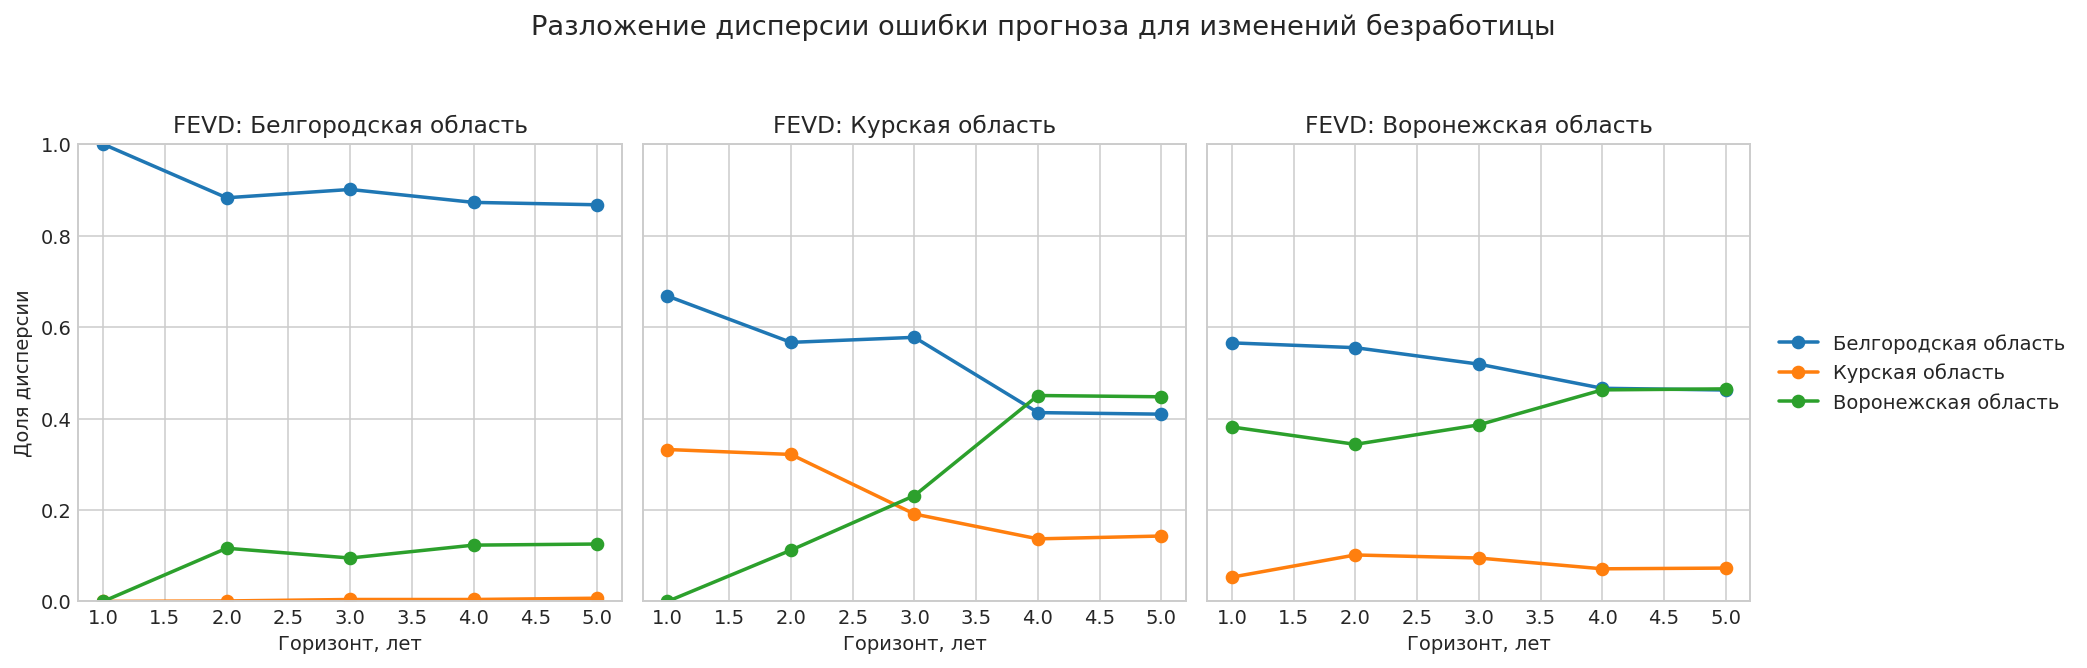

### Краткая интерпретация FEVD

- Для `Белгородская область` на горизонте 5 лет собственные шоки объясняют `0.867` дисперсии, а крупнейший внешний вклад дает `Воронежская область`: `0.126`.
- Для `Курская область` на горизонте 5 лет собственные шоки объясняют `0.143` дисперсии, а крупнейший внешний вклад дает `Воронежская область`: `0.448`.
- Для `Воронежская область` на горизонте 5 лет собственные шоки объясняют `0.465` дисперсии, а крупнейший внешний вклад дает `Белгородская область`: `0.462`.
- Это означает, что динамика изменений безработицы по регионам не полностью автономна: для части регионов межрегиональные шоки заметно влияют на ошибку прогноза. Особенно это заметно для Курской области, где внешний вклад велик.


FEVD-график сохранен: /Users/maria/Desktop/Code/HSE/TS/hw18/figures/var_fevd_5y.png


In [ ]:
fevd_horizon = 5
fevd_results = var_results.fevd(fevd_horizon)

fevd_rows = []
for response_idx, response_region in enumerate(regions):
    for horizon in range(1, fevd_horizon + 1):
        shares = fevd_results.decomp[response_idx, horizon - 1, :]
        row = {
            "отклик": response_region,
            "горизонт": horizon,
        }
        for impulse_idx, impulse_region in enumerate(regions):
            row[impulse_region] = shares[impulse_idx]
        fevd_rows.append(row)

fevd_table = pd.DataFrame(fevd_rows).round(4)
fevd_table.to_csv(TABLES_DIR / "fevd_table.csv", index=False, encoding="utf-8-sig")

fevd_horizon5_table = fevd_table[fevd_table["горизонт"] == fevd_horizon].copy()
fevd_horizon5_table.to_csv(TABLES_DIR / "fevd_horizon5_table.csv", index=False, encoding="utf-8-sig")
display(fevd_table)

fevd_fig_path = FIGURES_DIR / "var_fevd_5y.png"
fig, axes = plt.subplots(1, len(regions), figsize=(15, 4.5), sharey=True)

for response_idx, response_region in enumerate(regions):
    ax = axes[response_idx]
    subset = fevd_table[fevd_table["отклик"] == response_region]
    for impulse_region in regions:
        ax.plot(
            subset["горизонт"],
            subset[impulse_region],
            marker="o",
            linewidth=1.8,
            label=impulse_region,
        )
    ax.set_title(f"FEVD: {response_region}")
    ax.set_xlabel("Горизонт, лет")
    if response_idx == 0:
        ax.set_ylabel("Доля дисперсии")
    ax.set_ylim(0, 1)
    if response_idx == len(regions) - 1:
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

fig.suptitle("Разложение дисперсии ошибки прогноза для изменений безработицы", fontsize=14, y=1.05)
fig.tight_layout()
fig.savefig(fevd_fig_path, bbox_inches="tight")
plt.show()

own_share_rows = []
for _, row in fevd_horizon5_table.iterrows():
    response_region = row["отклик"]
    own_share = row[response_region]
    external_shares = row[regions].drop(labels=[response_region])
    main_external_region = external_shares.idxmax()
    own_share_rows.append(
        f"- Для `{response_region}` на горизонте {fevd_horizon} лет собственные шоки объясняют `{own_share:.3f}` дисперсии, "
        f"а крупнейший внешний вклад дает `{main_external_region}`: `{external_shares.max():.3f}`."
    )


print("FEVD-график сохранен:", fevd_fig_path)

,год,изменение: Белгородская область,изменение: Курская область,изменение: Воронежская область,уровень: Белгородская область,уровень: Курская область,уровень: Воронежская область
0,2023,0.1459,-0.2861,-1.3666,3.8459,2.6139,2.1334
1,2024,-0.3644,-1.3242,-0.7130,3.4815,1.2897,1.4204
2,2025,-0.3031,-0.5164,-0.4661,3.1784,0.7734,0.9543


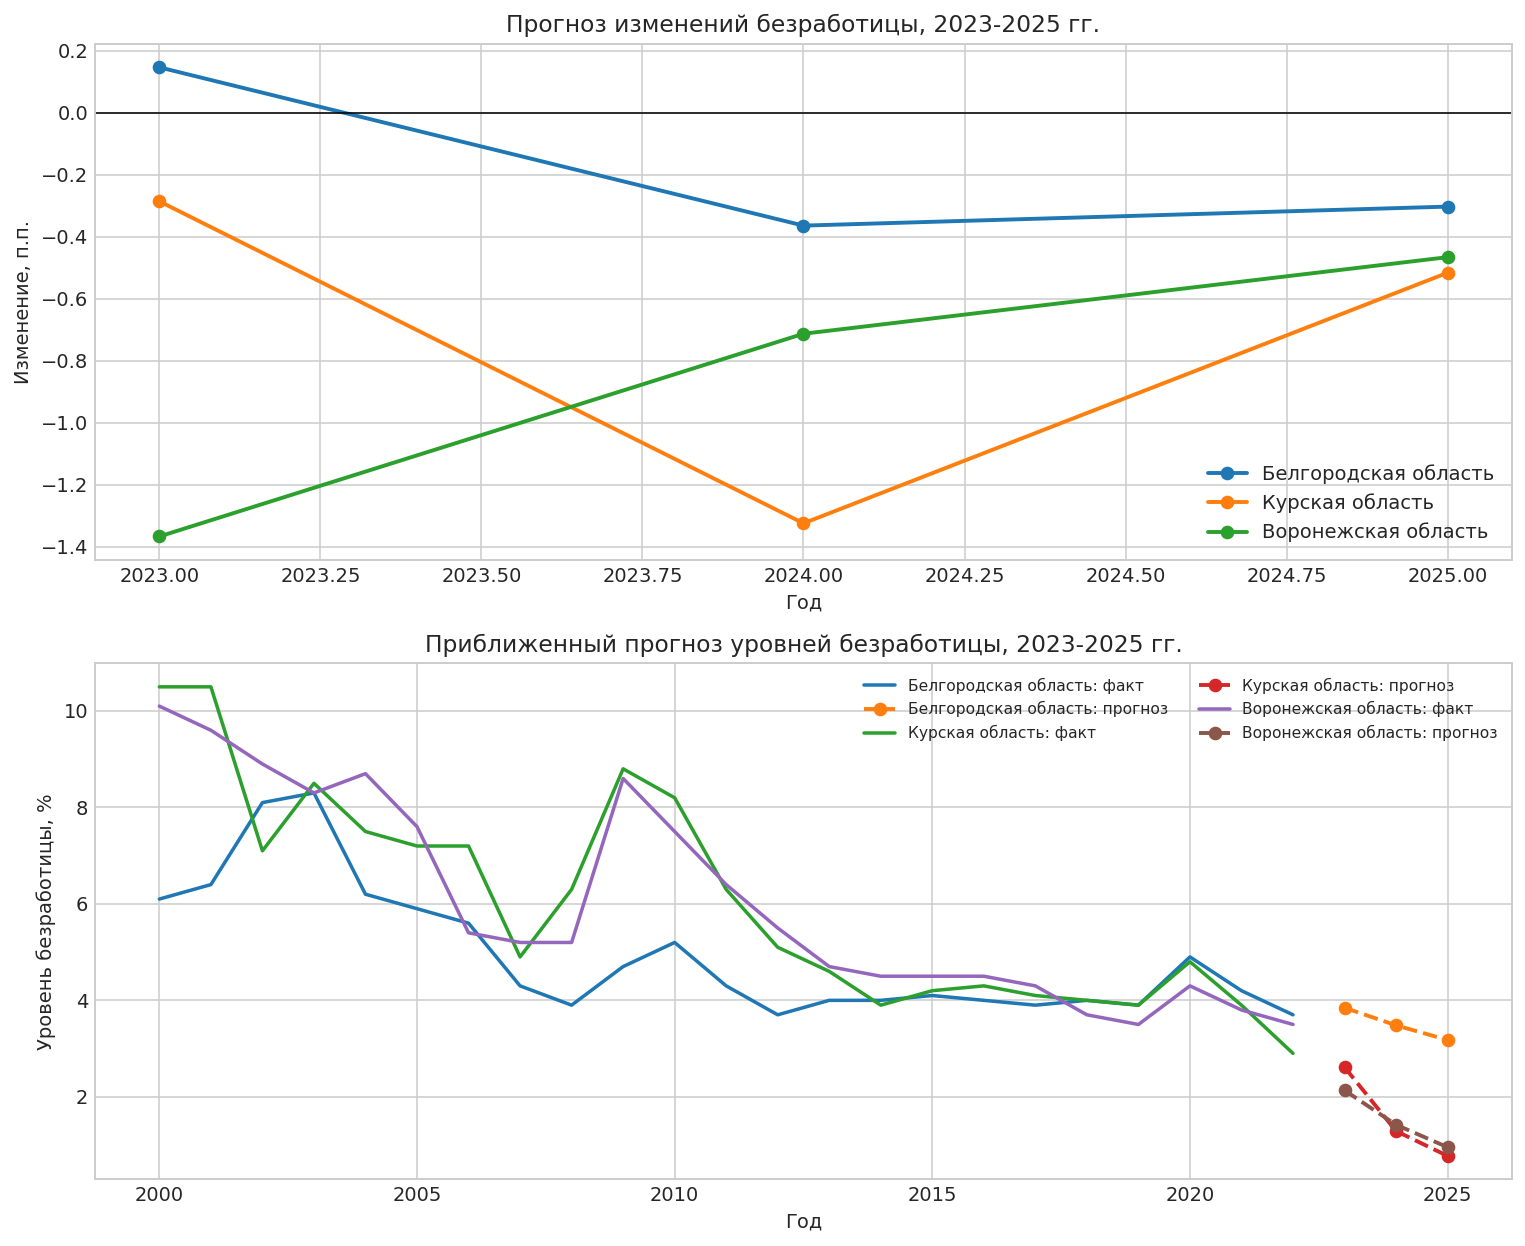

### Краткая интерпретация прогноза

- Прогноз построен только на `3` шага вперед, поэтому его следует считать строго краткосрочным.
- Из `9` прогнозных значений изменений безработицы `8` оказываются отрицательными, то есть модель в большинстве случаев ожидает дальнейшее снижение безработицы по сравнению с предыдущим годом.
- Восстановленные уровни нужно трактовать как механическое приближение на основе прогнозов первых разностей, а не как точную структурную траекторию.
- Из-за малого объема выборки и насыщенности VAR(3) прогноз носит исследовательский характер.


Таблица прогноза сохранена: /Users/maria/Desktop/Code/HSE/TS/hw18/tables/forecast_table.csv
График прогноза сохранен: /Users/maria/Desktop/Code/HSE/TS/hw18/figures/var_forecast_changes_levels.png


In [ ]:
forecast_steps = 3
forecast_index = pd.period_range(start=analysis_df.index[-1] + 1, periods=forecast_steps, freq="Y")
forecast_diff_values = var_results.forecast(analysis_df.values[-selected_lag:], steps=forecast_steps)

forecast_diff_df = pd.DataFrame(forecast_diff_values, index=forecast_index, columns=regions)
forecast_levels_df = forecast_diff_df.cumsum().add(ts_df.iloc[-1], axis=1)

forecast_table = pd.DataFrame({"год": [period.year for period in forecast_index]})
for region in regions:
    forecast_table[f"изменение: {region}"] = forecast_diff_df[region].values
for region in regions:
    forecast_table[f"уровень: {region}"] = forecast_levels_df[region].values

forecast_table = forecast_table.round(4)
forecast_table.to_csv(TABLES_DIR / "forecast_table.csv", index=False, encoding="utf-8-sig")
display(forecast_table)

forecast_fig_path = FIGURES_DIR / "var_forecast_changes_levels.png"
fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=False)

for region in regions:
    axes[0].plot(
        forecast_table["год"],
        forecast_table[f"изменение: {region}"],
        marker="o",
        linewidth=2,
        label=region,
    )
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Прогноз изменений безработицы, 2023-2025 гг.")
axes[0].set_xlabel("Год")
axes[0].set_ylabel("Изменение, п.п.")
axes[0].legend()

history_years = ts_df.index.year
for region in regions:
    axes[1].plot(history_years, ts_df[region].values, linewidth=1.8, label=f"{region}: факт")
    axes[1].plot(
        forecast_table["год"],
        forecast_table[f"уровень: {region}"],
        linestyle="--",
        marker="o",
        linewidth=2,
        label=f"{region}: прогноз",
    )
axes[1].set_title("Приближенный прогноз уровней безработицы, 2023-2025 гг.")
axes[1].set_xlabel("Год")
axes[1].set_ylabel("Уровень безработицы, %")
axes[1].legend(ncol=2, fontsize=8)

fig.tight_layout()
fig.savefig(forecast_fig_path, bbox_inches="tight")
plt.show()

negative_diff_count = int((forecast_diff_df < 0).sum().sum())
total_diff_count = int(forecast_diff_df.size)

print("Таблица прогноза сохранена:", TABLES_DIR / "forecast_table.csv")
print("График прогноза сохранен:", forecast_fig_path)